# District data cleaning (fixed)

Changes from the original notebook:

- `" Matu Daro"` key had a leading space, so the crime rows for Matu Daro were never merged into `Matu/Daro`. The key is corrected.
- `Serdang` (a police district under Petaling, see the original note) had no entry in any map. It is now merged into `Petaling`.
- District names are resolved through the maps until they stop changing, so one pass gives the final name (the original relied on running the loop several times).
- `Padawan` (and `Siburan`, which was mapped to it) is merged into `Kuching`. Padawan enrolment starts in 2023, when Kuching's enrolment drops by about the same amount, so summing restores a continuous series.
- Count columns (population, schools, students, crimes) are still summed.
- Rate and level columns (income, poverty, gini, amenities) are combined with a population-weighted mean instead of a sum.
- Missing amenities values stay missing instead of becoming 0.

## Changes in this version (modelling)

The cleaning and joining cells are unchanged. New or changed cells have `# Why:` and `# What:` comments.

- After the original 2022 → 2023 evaluation, two check cells compare the score with a last-year baseline and check how close the random forest's 2023 predictions are to each district's 2022 rate.
- A comment is added to the 2023 income imputation cell (code unchanged).
- New section **Cross-sectional model** at the end:
  - target is the 2020–2023 average crime rate per district
  - features come from 2022, with poverty, gini, income_mean, piped_water and age/sex shares added
  - state is added as a one-hot feature
  - models are compared with repeated 5-fold cross-validation over districts
  - a pooled 2020–2023 panel with `GroupKFold` is included as an alternative
- New section **Insights**: correlations, state rates, residuals, permutation importance, and k-means without the crime columns.
- New section **Model improvements** at the end: survey features averaged over 2019 and 2022, post-secondary and tertiary features, Poisson GLM + state with `alpha=0.1`, and the average of the ridge and Poisson predictions.
- The final model cell and the `crime_model.joblib` save cell are unchanged, so the Streamlit app still loads the original random forest.

In [1]:
# pandas for tables, numpy for numeric operations (log, square root, weighted average)
import pandas as pd
import numpy as np

In [2]:
# Loads the eight raw district datasets from the data folder.

crime_raw = pd.read_csv('data/crime_district.csv')
amenities_raw = pd.read_csv('data/hh_access_amenities.csv')
income_raw = pd.read_csv('data/hh_income_district.csv')
inequality_raw = pd.read_csv('data/hh_inequality_district.csv')
poverty_raw = pd.read_csv('data/hh_poverty_district.csv')
population_raw = pd.read_csv('data/population_district.csv')
schools_raw = pd.read_csv('data/schools_district.csv')
enrolment_raw = pd.read_csv('data/enrolment_school_district.csv')

# With all dataframes in one dictionary, the cleaning steps below can loop over them by name
raw_df = {
    'income': income_raw, 'poverty': poverty_raw, 'inequality': inequality_raw,
    'amenities': amenities_raw, 'population': population_raw, 'crime': crime_raw,
    'schools': schools_raw, 'enrolment': enrolment_raw,
}

In [3]:
# Removes the summary rows from every raw table: districts named 'All' or 'All Districts', and state 'Malaysia'.
# these rows are totals of other rows. If they were kept, the same crimes or people would be counted twice
# when districts are added together later.
for table_name in raw_df:
    table = raw_df[table_name]
    keep_rows = ~table['district'].isin(['All', 'All Districts']) & (table['state'] != 'Malaysia')
    raw_df[table_name] = table[keep_rows]

## Name maps

The districts are not consistent across datasets. Crime data uses IPD (police) districts, education data uses PPD districts, and the rest use administrative districts. Names are respelled, and sub-units are merged into the district that carries the data in the other datasets. The IPD merges below are the ones recorded in the original notebook (as of 29 Sep 2026).

In [4]:
# dictionaries that translate district names from each dataset into one common set of names.
# the datasets use different district systems (police, education and administrative districts) and
# different spellings, so the same place can appear under several names. Rows can only be joined
# once every dataset uses the same name for the same place.

# federal territories are written with a "W.P." prefix in some files
federal_territory_renames = {
    "W.P. Kuala Lumpur": "Kuala Lumpur",
    "W.P. Labuan": "Labuan",
    "W.P. Putrajaya": "Putrajaya"
}

# spelling / naming differences only; the area covered does not change
spelling_renames = {
    "Kulaijaya": "Kulai", "Ledang": "Tangkak", "Bandar Bharu": "Bandar Baharu",
    "Pasir Putih": "Pasir Puteh", "Cameron Highland": "Cameron Highlands",
    "Kuala Lipis": "Lipis", "Larut & Matang": "Larut dan Matang",
    "Larut Dan Matang": "Larut dan Matang", "Larut Matang & Selama": "Larut/Matang/Selama",
    "Manjung (Dinding)": "Manjung", "Jpn Perlis": "Perlis",
    "S.P. Selatan": "Seberang Perai Selatan", "Sp Selatan": "Seberang Perai Selatan",
    "S.P.Tengah": "Seberang Perai Tengah", "Sp Tengah": "Seberang Perai Tengah",
    "S.P.Utara": "Seberang Perai Utara", "Sp Utara": "Seberang Perai Utara",
    "Kota Kinabatangan": "Kinabatangan", "Pensiangan": "Nabawan",
    "Kota Samarahan": "Samarahan", "Lubok antu": "Lubok Antu", "Meradong": "Maradong",
    "Hulu Langat": "Ulu Langat", "Hulu Selangor": "Ulu Selangor", "Sg. Buloh": "Sungai Buloh",
    "Hulu": "Hulu Terengganu"
}

# smaller units (police districts, towns) that are inside a larger administrative district
sub_districts_to_parents = {
    "Johor Bahru Selatan": "Johor Bahru", "Johor Bahru Utara": "Johor Bahru",
    "Iskandar Puteri": "Johor Bahru", "Nusajaya": "Johor Bahru",
    "Seri Alam": "Johor Bahru", "Pasir Gudang": "Johor Bahru",
    "Nilai": "Seremban", "Ipoh": "Kinta", "Batu Gajah": "Kinta",
    "Kinta Selatan": "Kinta", "Kinta Utara": "Kinta", "Sungai Siput": "Kuala Kangsar",
    "Gerik": "Hulu Perak", "Pengkalan Hulu": "Hulu Perak", "Tapah": "Batang Padang",
    "Tanjong Malim": "Muallim", "Taiping": "Larut dan Matang",
    "Arau": "Perlis", "Kangar": "Perlis", "Padang Besar": "Perlis",
    "Ampang Jaya": "Ulu Langat", "Kajang": "Ulu Langat", "Klang Selatan": "Klang",
    "Klang Utara": "Klang", "Petaling Jaya": "Petaling", "Subang Jaya": "Petaling",
    "Shah Alam": "Petaling", "Sungai Buloh": "Petaling", "Petaling Perdana": "Petaling",
    "Petaling Utama": "Petaling", "Brickfields": "Kuala Lumpur",
    "Cheras": "Kuala Lumpur", "Dang Wangi": "Kuala Lumpur",
    "Sentul": "Kuala Lumpur", "Wangsa Maju": "Kuala Lumpur",
    # Serdang is its own police district but is under Petaling administratively
    "Serdang": "Petaling"
}

# districts that are combined into one joint unit (for example Kuala Muda and Yan become 'Kuala Muda/Yan'),
# so that every dataset reports the same area
districts_to_combined = {
    "Kuala Muda": "Kuala Muda/Yan", "Yan": "Kuala Muda/Yan",
    "Kulim": "Kulim/Bandar Baharu", "Bandar Baharu": "Kulim/Bandar Baharu",
    "Jempol": "Jempol/Jelebu", "Jelebu": "Jempol/Jelebu",
    "Larut dan Matang": "Larut/Matang/Selama", "Selama": "Larut/Matang/Selama",
    "Telupid": "Telupid/Tongod", "Tongod": "Telupid/Tongod",
    "Tatau": "Tatau/Sebauh", "Sebauh": "Tatau/Sebauh",
    "Matu": "Matu/Daro", "Daro": "Matu/Daro", "Matu Daro": "Matu/Daro"
}

# districts with no crime data of their own, merged into the police district (IPD) that covers them
police_district_merges = {
    "Pokok Sena": "Kota Setar",
    "Kecil Lojing": "Gua Musang",
    "Bagan Datuk": "Hilir Perak",
    "Kuala Nerus": "Kuala Terengganu",
    "Kalabakan": "Tawau",
    "Kuala Penyu": "Beaufort", "Membakut": "Beaufort",
    "Nabawan": "Keningau", "Tambunan": "Keningau",
    "Pitas": "Kota Marudu",
    "Putatan": "Penampang",
    "Telupid/Tongod": "Beluran",
    "Asajaya": "Samarahan",
    "Beluru": "Marudi", "Telang Usan": "Marudi", "Baram": "Marudi",
    "Bukit Mabong": "Kapit",
    "Gedong": "Simunjan",
    "Kabong": "Saratok", "Pusa": "Saratok",
    "Lingga": "Sri Aman", "Pantu": "Sri Aman", "Sebuyau": "Sri Aman",
    "Pakan": "Julau",
    "Selangau": "Mukah",
    "Siburan": "Padawan",
    "Padawan": "Kuching",
    "Subis": "Miri",
    "Tanjung Manis": "Sarikei",
    "Tebedu": "Serian",
}

district_name_map = {**spelling_renames, **sub_districts_to_parents,
                     **districts_to_combined, **police_district_merges, **federal_territory_renames}

`resolve_district_name` follows the maps until the name stops changing, so a chain such as `Telupid` -> `Telupid/Tongod` -> `Beluran` is handled in one pass. `apply_spelling_fixes` applies only the respelling maps and gives the unit name used to look up population weights.

In [5]:
# functions that turn a raw district name into the common name.

def resolve_district_name(district_name):
    # a name can map to another name that is itself in the map
    # (for example 'Telupid' -> 'Telupid/Tongod' -> 'Beluran'), so the name is looked up again
    # until it is no longer in the map. seen ends the loop if two names ever map to each other.
    seen = set()
    while district_name in district_name_map and district_name not in seen:
        seen.add(district_name)
        district_name = district_name_map[district_name]
    return district_name

# the rate tables (income, poverty, ...) are weighted by the population of each original unit, 
# so a second name is needed that only fixes the spelling and does not merge units together.
spelling_only_map = {**spelling_renames, **federal_territory_renames}

def apply_spelling_fixes(district_name):
    # returns the respelled name, or the same name if it has no spelling fix
    return spelling_only_map.get(district_name, district_name)

def standardise_labels(table):
    # returns a copy of the table with cleaned state names and two district columns:
    # - 'unit': the original district with only the spelling fixed (used to look up population weights)
    # - 'district': the final common district name (used to group and join)
    labelled = table.copy()
    # removes spaces at the start and end, so ' Matu Daro' matches the key 'Matu Daro'
    labelled['state'] = labelled['state'].str.strip()
    labelled['district'] = labelled['district'].str.strip()
    # Putrajaya and Labuan are their own states (crime data nests Putrajaya under Kuala Lumpur)
    labelled.loc[labelled['district'].isin(['W.P. Putrajaya', 'Putrajaya']), 'state'] = 'Putrajaya'
    labelled.loc[labelled['district'].isin(['W.P. Labuan', 'Labuan']), 'state'] = 'Labuan'
    labelled['state'] = labelled['state'].replace(federal_territory_renames)
    labelled['unit'] = labelled['district'].map(apply_spelling_fixes)
    labelled['district'] = labelled['district'].map(resolve_district_name)
    return labelled

# # Count datasets

Population, schools, students and crimes are counts, so merged districts are summed.

In [6]:
# cleans the four count tables (population, schools, enrolment, crime).
# these columns are counts, so when several raw districts are merged into one district,
# the merged value is the sum of its parts.
count_group_columns = ['state', 'district', 'date', 'category', 'type', 'stage', 'sex', 'age', 'ethnicity']

def combine_counts(raw_table):
    labelled = standardise_labels(raw_table).drop(columns='unit')
    # groups only by the columns this table has (crime has category and type, population has sex, age, ethnicity, ...)
    group_columns = [column for column in count_group_columns if column in labelled.columns]
    # rows that now share the same district (and the same date, category, ...) are added together
    return labelled.groupby(group_columns).sum().reset_index()

clean_tables = {table_name: combine_counts(raw_df[table_name])
                for table_name in ['population', 'schools', 'enrolment', 'crime']}

## Rate and level datasets

Income, poverty, gini and the amenities percentages cannot be summed. Rows that merge into one district are combined with a mean weighted by the population of each unit (both sexes, all ages, all ethnicities).
Weighted mean approach is taken because: 
- Districts are combined together to account for crime
- Every district has a different population and household count. A simple mean approach would treat a dense district the same as a sparsely populated district

- Population is available for 2020-2025. Rows dated before 2020 use the 2020 population.
- If any contributing unit has no population row (Membakut, Gedong, Sebuyau, Pantu, Lingga, Siburan), the group uses a simple mean. These groups are listed below.
- Missing values are skipped. A group with no values stays missing.
- Weighted means of medians and of gini are approximations, since the underlying household data is not available.

In [7]:
# population weights for the rate tables: total population (both sexes, all ages, all ethnicities)
# per state, original unit and year.
# when several units are merged into one district, a unit with more people should count more towards the
# merged income or poverty value than a unit with fewer people.
population_rows = standardise_labels(raw_df['population'])
is_total_row = (population_rows['sex'] == 'both') & (population_rows['age'] == 'overall') & (population_rows['ethnicity'] == 'overall')
population_rows = population_rows[is_total_row]
population_rows['weight_year'] = population_rows['date'].str[:4].astype(int)
unit_weights = population_rows.groupby(['state', 'unit', 'weight_year'])['population'].sum().rename('unit_population').reset_index()

In [8]:
# population unit names, used to check which units have a weight
population_rows['unit'].unique()

array(['Batu Pahat', 'Johor Bahru', 'Kluang', 'Kota Tinggi', 'Kulai',
       'Mersing', 'Muar', 'Pontian', 'Segamat', 'Tangkak', 'Baling',
       'Bandar Baharu', 'Kota Setar', 'Kuala Muda', 'Kubang Pasu',
       'Kulim', 'Langkawi', 'Padang Terap', 'Pendang', 'Pokok Sena',
       'Sik', 'Yan', 'Bachok', 'Gua Musang', 'Jeli', 'Kecil Lojing',
       'Kota Bharu', 'Kuala Krai', 'Machang', 'Pasir Mas', 'Pasir Puteh',
       'Tanah Merah', 'Tumpat', 'Alor Gajah', 'Jasin', 'Melaka Tengah',
       'Jelebu', 'Jempol', 'Kuala Pilah', 'Port Dickson', 'Rembau',
       'Seremban', 'Tampin', 'Bentong', 'Bera', 'Cameron Highlands',
       'Jerantut', 'Kuantan', 'Lipis', 'Maran', 'Pekan', 'Raub', 'Rompin',
       'Temerloh', 'Bagan Datuk', 'Batang Padang', 'Hilir Perak',
       'Hulu Perak', 'Kampar', 'Kerian', 'Kinta', 'Kuala Kangsar',
       'Larut dan Matang', 'Manjung', 'Muallim', 'Perak Tengah', 'Selama',
       'Perlis', 'Barat Daya', 'Seberang Perai Selatan',
       'Seberang Perai Tengah', '

In [9]:
# cleans the rate tables (income, poverty, inequality, amenities). For every state, district and date,
# each column is combined over the units merged into that district:
# - no value: stays missing
# - one value: kept as it is
# - several values, all units have a population row: population-weighted mean
# - several values, at least one unit has no population row: simple mean, and the group is recorded in fallback_groups
# rates and averages cannot be added together like counts. 
# A weighted mean keeps the merged value between the values of its parts, closer to the units with more people.
fallback_groups = []

def combine_rates(table_name, rate_columns):
    labelled = standardise_labels(raw_df[table_name])
    # population data starts in 2020, so earlier survey years (for example 2019) use the 2020 population as weight
    labelled['weight_year'] = labelled['date'].str[:4].astype(int).clip(2020, 2025)
    labelled = labelled.merge(unit_weights, on=['state', 'unit', 'weight_year'], how='left')
    merged_rows = []
    for (state, district, date), group in labelled.groupby(['state', 'district', 'date']):
        merged_row = {'state': state, 'district': district, 'date': date}
        for column in rate_columns:
            values = group[column].dropna()
            # weights of the same rows as the non-missing values
            weights = group.loc[values.index, 'unit_population']
            if len(values) == 0:
                merged_row[column] = np.nan
            elif len(values) == 1:
                merged_row[column] = values.iloc[0]
            elif weights.isna().any() or (weights <= 0).any():
                merged_row[column] = values.mean()
                fallback_groups.append((table_name, state, district, date, sorted(group['unit'])))
            else:
                merged_row[column] = np.average(values, weights=weights)
        merged_rows.append(merged_row)
    # the labelled table (before merging) is also returned, so the check cells can compare against it
    return pd.DataFrame(merged_rows), labelled

rate_columns_by_table = {
    'income': ['income_mean', 'income_median'],
    'poverty': ['poverty_absolute', 'poverty_relative'],
    'inequality': ['gini'],
    'amenities': ['piped_water', 'sanitation', 'electricity'],
}

rates_before_merge = {}
for table_name, rate_columns in rate_columns_by_table.items():
    clean_tables[table_name], rates_before_merge[table_name] = combine_rates(table_name, rate_columns)

In [10]:
# groups that used a simple mean because at least one unit has no population row (one row per group)
pd.DataFrame(fallback_groups, columns=['dataset', 'state', 'district', 'date', 'units']).drop_duplicates(subset=['dataset', 'state', 'district', 'date'])

,dataset,state,district,date,units
0,income,Sabah,Beaufort,2024-01-01,"[Beaufort, Kuala Penyu, Membakut]"
2,income,Sarawak,Kuching,2024-01-01,"[Kuching, Siburan]"
4,income,Sarawak,Simunjan,2024-01-01,"[Gedong, Simunjan]"
6,income,Sarawak,Sri Aman,2024-01-01,"[Lingga, Pantu, Sebuyau, Sri Aman]"
8,poverty,Sabah,Beaufort,2024-01-01,"[Beaufort, Kuala Penyu, Membakut]"
10,poverty,Sarawak,Kuching,2024-01-01,"[Kuching, Siburan]"
12,poverty,Sarawak,Simunjan,2024-01-01,"[Gedong, Simunjan]"
14,poverty,Sarawak,Sri Aman,2024-01-01,"[Lingga, Pantu, Sebuyau, Sri Aman]"
16,inequality,Sabah,Beaufort,2024-01-01,"[Beaufort, Kuala Penyu, Membakut]"
17,inequality,Sarawak,Kuching,2024-01-01,"[Kuching, Siburan]"


# # Checks

In [11]:
# number of rows in each table before and after cleaning.
# dropping summary rows and merging districts lowers the row count; this shows by how much for each table.
pd.DataFrame({'raw': {table_name: len(table) for table_name, table in raw_df.items()},
              'clean': {table_name: len(table) for table_name, table in clean_tables.items()}})

,raw,clean
income,480,389
poverty,480,389
inequality,480,389
amenities,640,524
population,383040,313614
crime,17472,14672
schools,3569,3138
enrolment,11433,10149


In [12]:
# checks the two names that were not merged correctly in the previous versions of this notebook.
# - 'Matu Daro' and 'Serdang' should no longer appear as separate crime districts
# - prints the years of crime data for Matu/Daro
# - prints whether Petaling's cleaned crime total is larger than the raw 'Petaling' rows alone
# (True means the sub-districts, including Serdang, were added to it)
for table_name in ['crime']:
    cleaned = clean_tables[table_name]
    assert 'Matu Daro' not in set(cleaned['district'])
    assert 'Serdang' not in set(cleaned['district'])
print(clean_tables['crime'].query("district == 'Matu/Daro'")['date'].str[:4].unique())
print(clean_tables['crime'].query("district == 'Petaling'")['crimes'].sum() > raw_df['crime'].query("district == 'Petaling'")['crimes'].sum())

['2016' '2017' '2018' '2019' '2020' '2021' '2022' '2023']
True


In [13]:
# checks that every merged rate lies between the smallest and largest value of the units it was made from.
# a weighted or simple mean cannot fall outside that range, so a value outside it would mean the wrong rows
# were combined. The 1e-9 margin allows for floating-point rounding.
for table_name, rate_columns in rate_columns_by_table.items():
    before_merge = rates_before_merge[table_name]
    member_range = before_merge.groupby(['state', 'district', 'date'])[rate_columns].agg(['min', 'max'])
    merged = clean_tables[table_name].set_index(['state', 'district', 'date'])
    for column in rate_columns:
        within_range = merged[column].isna() | ((merged[column] >= member_range[(column, 'min')] - 1e-9) & (merged[column] <= member_range[(column, 'max')] + 1e-9))
        assert within_range.all(), (table_name, column)
print('rates within member range')

rates within member range


In [14]:
# prints the largest value, the number of missing values and the number of zeros in each amenities column,
# and checks that no percentage is above 100.
# the original notebook turned missing amenities values into 0. This confirms they now stay missing.
amenities_clean = clean_tables['amenities']
amenity_columns = ['piped_water', 'sanitation', 'electricity']
print(amenities_clean[amenity_columns].max())
print(amenities_clean[amenity_columns].isna().sum())
print((amenities_clean[amenity_columns] == 0).sum())
assert (amenities_clean[amenity_columns].max() <= 100 + 1e-9).all()

piped_water    100.0
sanitation     100.0
electricity    100.0
dtype: float64
piped_water    1
sanitation     1
electricity    1
dtype: int64
piped_water    0
sanitation     0
electricity    0
dtype: int64


In [15]:
# example of a merged rate district: Marudi combines several units in the income and inequality tables
clean_tables['income'].query("district == 'Marudi'").merge(clean_tables['inequality'].query("district == 'Marudi'"), on=['state', 'district', 'date'])

,state,district,date,income_mean,income_median,gini
0,Sarawak,Marudi,2019-01-01,4339.141757,3257.186441,0.361582
1,Sarawak,Marudi,2022-01-01,4970.361371,4104.816199,0.321717
2,Sarawak,Marudi,2024-01-01,5038.156550,4378.782748,0.256367


In [16]:
# for each clean table, the first and last year with data for each state and district, written as 'first-last'.
# An empty entry means the district has no rows in that table.
# shows which years each dataset covers, and whether a district is missing from any dataset.
year_range_columns = []
for table_name, table in clean_tables.items():
    year_span = table.assign(year=table['date'].str[:4]).groupby(['state', 'district'])['year'].agg(['min', 'max'])
    year_range_columns.append((year_span['min'] + '-' + year_span['max']).rename(table_name))

years_with_data = pd.concat(year_range_columns, axis=1).fillna('')
years_with_data.loc['Sarawak']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Bau,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Belaga,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Betong,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Bintulu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Dalat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Julau,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kanowit,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kapit,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuching,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [17]:
years_with_data.loc['Selangor']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Gombak,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Klang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Langat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Selangor,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Petaling,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Sabak Bernam,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Sepang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Ulu Langat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Ulu Selangor,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [18]:
years_with_data.loc['Johor']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Batu Pahat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Johor Bahru,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kluang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Tinggi,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kulai,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Mersing,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Muar,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pontian,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Segamat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [19]:
years_with_data.loc['Kedah']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Baling,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Setar,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Muda/Yan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kubang Pasu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kulim/Bandar Baharu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Langkawi,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Padang Terap,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pendang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Sik,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [20]:
years_with_data.loc['Kelantan']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Bachok,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Gua Musang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Jeli,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Bharu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Krai,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Machang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pasir Mas,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pasir Puteh,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Tanah Merah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [21]:
years_with_data.loc['Kuala Lumpur']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Kuala Lumpur,2020-2025,2017-2025,2017-2025,2016-2023,2019-2022,2019-2022,2019-2022,2016-2024


In [22]:

years_with_data.loc['Labuan']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Labuan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2022,2019-2022,2019-2022,2016-2024


In [23]:

years_with_data.loc['Melaka']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Alor Gajah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Jasin,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Melaka Tengah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [24]:
 Negeri Sembilan
years_with_data.loc['Negeri Sembilan']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Jempol/Jelebu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Pilah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Port Dickson,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Rembau,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Seremban,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Tampin,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [25]:
years_with_data.loc['Pulau Pinang']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Barat Daya,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Seberang Perai Selatan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Seberang Perai Tengah,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Seberang Perai Utara,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Timur Laut,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [26]:
years_with_data.loc['Perlis']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Perlis,2020-2025,2017-2025,2017-2025,2016-2023,2019-2022,2019-2022,2019-2022,2016-2024


In [27]:
years_with_data.loc['Perak']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Batang Padang,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Hilir Perak,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Hulu Perak,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kampar,2020-2025,2017-2025,2018-2022,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kerian,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kinta,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuala Kangsar,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Larut/Matang/Selama,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Manjung,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [28]:
years_with_data.loc['Pahang']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Bentong,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Bera,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Cameron Highlands,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Jerantut,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kuantan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Lipis,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Maran,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Pekan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Raub,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [29]:
years_with_data.loc['Putrajaya']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Putrajaya,2020-2025,2017-2025,2017-2025,2016-2023,2019-2022,2019-2022,2019-2022,2016-2024


In [30]:
years_with_data.loc['Sabah']

,population,schools,enrolment,crime,income,poverty,inequality,amenities
district,,,,,,,,
Beaufort,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Beluran,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Keningau,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kinabatangan,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Belud,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Kinabalu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kota Marudu,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kudat,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024
Kunak,2020-2025,2017-2025,2017-2025,2016-2023,2019-2024,2019-2024,2019-2024,2016-2024


In [31]:
# districts that have an empty entry, i.e. are missing from one or more datasets (aggregate rows excluded)
years_without_aggregates = years_with_data[~years_with_data.index.get_level_values('district').isin(['All', 'All Districts'])]
years_without_aggregates[(years_without_aggregates == '').any(axis=1)]

,,population,schools,enrolment,crime,income,poverty,inequality,amenities
state,district,,,,,,,,


### These show that our merged data have crime recorded in every district, we can proceed with dropping summary columns (all, all districts), put at the beginning of notebook

# # Join by district

The eight tables are reduced to one row per state, district and year, then joined on those three columns.

- Year is taken from `date` (schools and enrolment are dated mid-year from 2023).
- Aggregate rows (`All`, `All Districts`) are dropped.
- Population uses the both / overall / overall rows.
- Crime uses the `all` type for each category (assault, property).
- Schools and students are split by stage. Students use `sex == 'both'`.
- The join is an outer join, so a district-year with data in any table is kept. Columns are NaN where a table has no data for that year.

In [32]:
# reshapes each clean table to one row per state, district and year, with one column per measure.
# the tables have different extra columns (sex, age, category, stage, ...). To join them, each table needs
# the same three key columns and only one row per key.
join_keys = ['state', 'district', 'year']

def prepare_for_join(table):
    # drops aggregate rows, turns 'date' (for example '2022-01-01') into a whole-number year and removes 'date'
    prepared = table[~table['district'].isin(['All', 'All Districts'])].copy()
    prepared['year'] = prepared['date'].str[:4].astype(int)
    return prepared.drop(columns='date')

# population: keeps only the total row (both sexes, all ages, all ethnicities)
population_prepared = prepare_for_join(clean_tables['population'])
population_totals = population_prepared[(population_prepared['sex'] == 'both') & (population_prepared['age'] == 'overall') & (population_prepared['ethnicity'] == 'overall')][join_keys + ['population']]

# crime: keeps the 'all' type of each category and turns the categories into columns (crimes_assault, crimes_property)
crime_prepared = prepare_for_join(clean_tables['crime'])
crime_wide = crime_prepared[crime_prepared['type'] == 'all'].pivot(index=join_keys, columns='category', values='crimes').add_prefix('crimes_').rename_axis(columns=None).reset_index()

# schools: one column per stage (schools_primary, ...); pivot_table adds up rows that share the same key and stage
schools_prepared = prepare_for_join(clean_tables['schools'])
schools_wide = schools_prepared.pivot_table(index=join_keys, columns='stage', values='schools', aggfunc='sum').add_prefix('schools_').rename_axis(columns=None).reset_index()

# enrolment: both sexes only, one column per stage (students_primary, ...)
enrolment_prepared = prepare_for_join(clean_tables['enrolment'])
enrolment_wide = enrolment_prepared[enrolment_prepared['sex'] == 'both'].pivot(index=join_keys, columns='stage', values='students').add_prefix('students_').rename_axis(columns=None).reset_index()

# the rate tables already have one row per state, district and date, so they only need the year column
rate_tables = [prepare_for_join(clean_tables[table_name]) for table_name in ['income', 'poverty', 'inequality', 'amenities']]

In [33]:
# joins the eight tables on state, district and year, adding one table at a time.
# an outer join keeps a district-year if any table has it, so no data is dropped. Columns from a table that
# has no data for that year are left as NaN.
tables_to_join = [population_totals, crime_wide, schools_wide, enrolment_wide] + rate_tables
df_district = tables_to_join[0]
for next_table in tables_to_join[1:]:
    df_district = df_district.merge(next_table, on=join_keys, how='outer')
df_district = df_district.sort_values(join_keys).reset_index(drop=True)
df_district

,state,district,year,population,crimes_assault,crimes_property,schools_primary,schools_secondary,schools_tertiary,students_post_secondary,students_primary,students_secondary,income_mean,income_median,poverty_absolute,poverty_relative,gini,piped_water,sanitation,electricity
0,Johor,Batu Pahat,2016,NaN,160.0,621.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.9,100.0,100.0
1,Johor,Batu Pahat,2017,NaN,123.0,558.0,144.0,32.0,1.0,NaN,37916.0,32997.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Johor,Batu Pahat,2018,NaN,104.0,584.0,144.0,32.0,1.0,2104.0,37173.0,29601.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Johor,Batu Pahat,2019,NaN,139.0,524.0,144.0,32.0,1.0,1911.0,36797.0,28659.0,7392.0,6504.0,2.9,9.0,0.295,100.0,100.0,100.0
4,Johor,Batu Pahat,2020,495.3,127.0,415.0,144.0,32.0,1.0,1056.0,36317.0,28329.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,Terengganu,Setiu,2021,60.5,5.0,38.0,43.0,14.0,0.0,168.0,7921.0,6281.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1306,Terengganu,Setiu,2022,61.5,11.0,40.0,43.0,14.0,0.0,137.0,7826.0,6596.0,6030.0,5211.0,7.5,6.0,0.275,97.2,100.0,100.0
1307,Terengganu,Setiu,2023,62.9,10.0,30.0,43.0,14.0,NaN,169.0,7802.0,6537.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1308,Terengganu,Setiu,2024,64.3,NaN,NaN,43.0,14.0,NaN,173.0,7685.0,6571.0,6359.0,6125.0,4.7,7.7,0.214,100.0,100.0,100.0


In [34]:
# checks there is only one row per state, district and year, then counts the non-missing values in each column
assert not df_district.duplicated(join_keys).any()
df_district.notna().sum()

state                      1310
district                   1310
year                       1310
population                  786
crimes_assault             1048
crimes_property            1048
schools_primary            1176
schools_secondary          1176
schools_tertiary            786
students_post_secondary    1035
students_primary           1174
students_secondary         1174
income_mean                 389
income_median               389
poverty_absolute            389
poverty_relative            389
gini                        389
piped_water                 523
sanitation                  523
electricity                 523
dtype: int64

In [35]:
# takes the 2022 rows and adds the derived columns used for clustering.
# 2022 is the only year with values in every column. Rates per 1,000 people are used instead of raw counts
# so that large and small districts can be compared. The log of population reduces the gap between very large
# and very small districts.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

districts_2022 = df_district[df_district['year'] == 2022].copy()
# population is in thousands, so crimes / population is crimes per 1,000 people
# (the same applies to students_pc and schools_pc: students and schools per 1,000 people)

districts_2022['assault_per_1000'] = districts_2022['crimes_assault'] / districts_2022['population']
districts_2022['property_per_1000'] = districts_2022['crimes_property'] / districts_2022['population']
districts_2022['students_pc'] = (districts_2022['students_primary'] + districts_2022['students_secondary']) / districts_2022['population']
districts_2022['schools_pc'] = (districts_2022['schools_primary'] + districts_2022['schools_secondary']) / districts_2022['population']
districts_2022['log_pop'] = np.log(districts_2022['population'])

# preliminary modelling showed that sanitation drives down the minority clusters, so it is dropped from the features
# cluster_features = ['log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median','poverty_relative', 'gini']

cluster_features = ['log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median']

# k-means works with distances, so each feature is scaled to mean 0 and standard deviation 1.
# Without this, income (values in the thousands) would outweigh the per-person rates (values below 1).

scaled_cluster_features = StandardScaler().fit_transform(districts_2022[cluster_features])

# # Choose k

Inertia (elbow) and silhouette score are computed for k = 2 to 10.

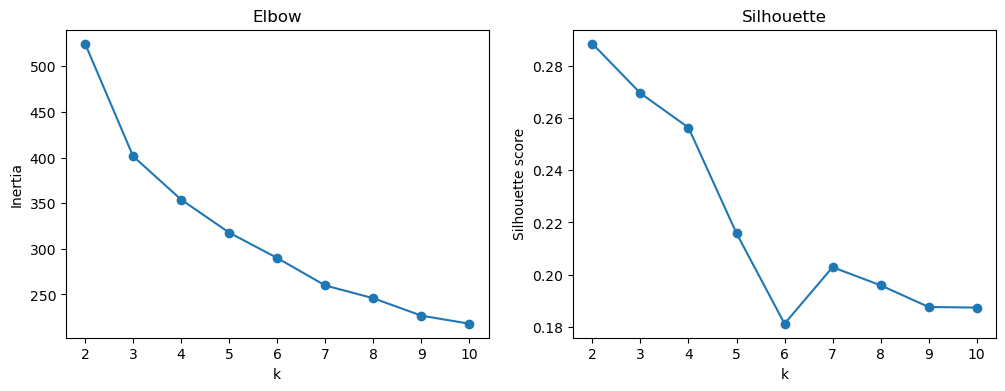

,k,inertia,silhouette
0,2,524.685263,0.288407
1,3,401.309793,0.269467
2,4,353.869121,0.256298
3,5,317.664342,0.215839
4,6,289.875427,0.181221
5,7,259.784811,0.202876
6,8,245.795625,0.195919
7,9,226.729948,0.187632
8,10,217.890847,0.187397


In [36]:
# fits k-means for k = 2 to 10 and records the inertia and silhouette score for each k.
# the number of clusters is not known in advance, so k is chosen by comparing these two measures:
# - inertia: total squared distance from each district to its cluster centre. It always goes down as k goes up,
# so the point where it stops dropping quickly (the "elbow") is used.
# - silhouette: how much closer each district is to its own cluster than to the nearest other cluster
# (higher is better).
# n_init=10 runs k-means from 10 different starting points and keeps the best result.
# random_state=0 gives the same result on every run.
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
inertias = []
silhouette_scores = []
for cluster_count in k_values:
    kmeans_model = KMeans(n_clusters=cluster_count, n_init=10, random_state=0).fit(scaled_cluster_features)
    inertias.append(kmeans_model.inertia_)
    silhouette_scores.append(silhouette_score(scaled_cluster_features, kmeans_model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title('Elbow')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(k_values, silhouette_scores, marker='o')
axes[1].set_title('Silhouette')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
plt.show()

pd.DataFrame({'k': k_values, 'inertia': inertias, 'silhouette': silhouette_scores})

# # Fit final model

In [37]:
# fits the final k-means with k = 3 and stores each district's cluster number in a new column.
# k = 3 was chosen from the elbow and silhouette results above (see the notes further down).
chosen_k = 3
kmeans_final = KMeans(n_clusters=chosen_k, n_init=10, random_state=0).fit(scaled_cluster_features)
districts_2022['cluster'] = kmeans_final.labels_
districts_2022['cluster'].value_counts().sort_index()

cluster
0    70
1    34
2    27
Name: count, dtype: int64

# # Profile clusters

In [38]:
# mean of each feature (unscaled) per cluster, to describe what each cluster contains
districts_2022.groupby('cluster')[cluster_features].mean()

,log_pop,assault_per_1000,property_per_1000,students_pc,schools_pc,income_median
cluster,,,,,,
0,5.035672,0.220592,0.883289,154.408417,0.449163,4623.485660
1,3.950228,0.151642,0.722161,206.599789,1.010125,3910.825800
2,6.162069,0.405381,1.533429,144.696055,0.233739,7229.088459


In [39]:
# number of districts from each state in each cluster
pd.crosstab(districts_2022['state'], districts_2022['cluster'])

cluster,0,1,2
state,,,
Johor,9,0,1
Kedah,4,0,5
Kelantan,10,0,0
Kuala Lumpur,0,0,1
Labuan,1,0,0
Melaka,2,0,1
Negeri Sembilan,3,2,1
Pahang,10,0,1
Perak,8,2,1


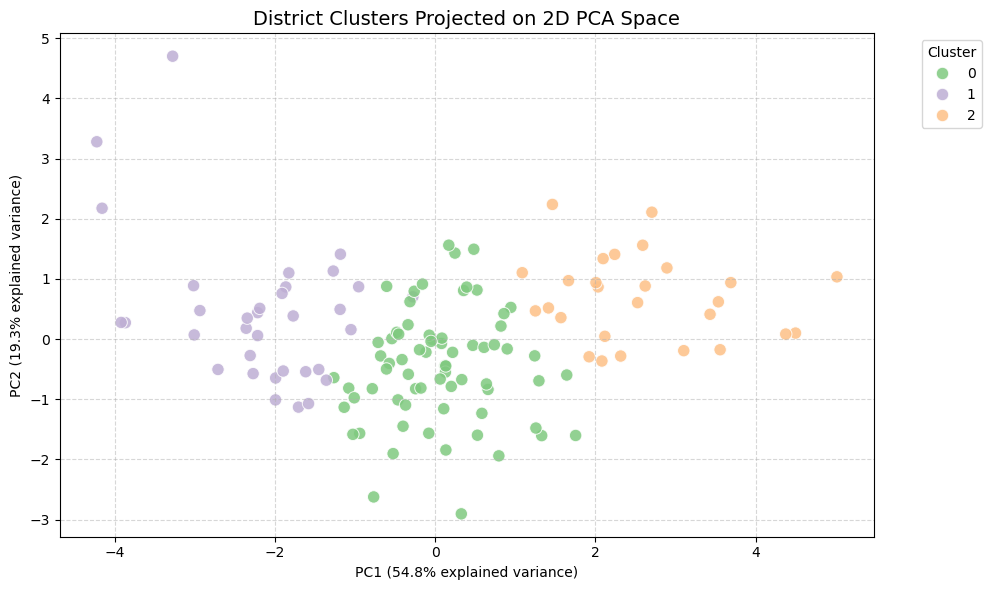

In [40]:
# projects the six scaled features onto 2 principal components and plots the districts coloured by cluster.
# the clusters are formed in 6 dimensions, which cannot be plotted directly. PCA finds the 2 directions with
# the most variation, so the plot keeps as much of the spread between districts as 2 axes allow.
# The axis labels show the share of the variance each component explains.
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca_model = PCA(n_components=2)
pca_coordinates = pca_model.fit_transform(scaled_cluster_features)

districts_2022['pca_1'] = pca_coordinates[:, 0]
districts_2022['pca_2'] = pca_coordinates[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=districts_2022,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='Accent',
    s=80,
    alpha=0.85
)

plt.title('District Clusters Projected on 2D PCA Space', fontsize=14)
plt.xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.1%} explained variance)')
plt.ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.1%} explained variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

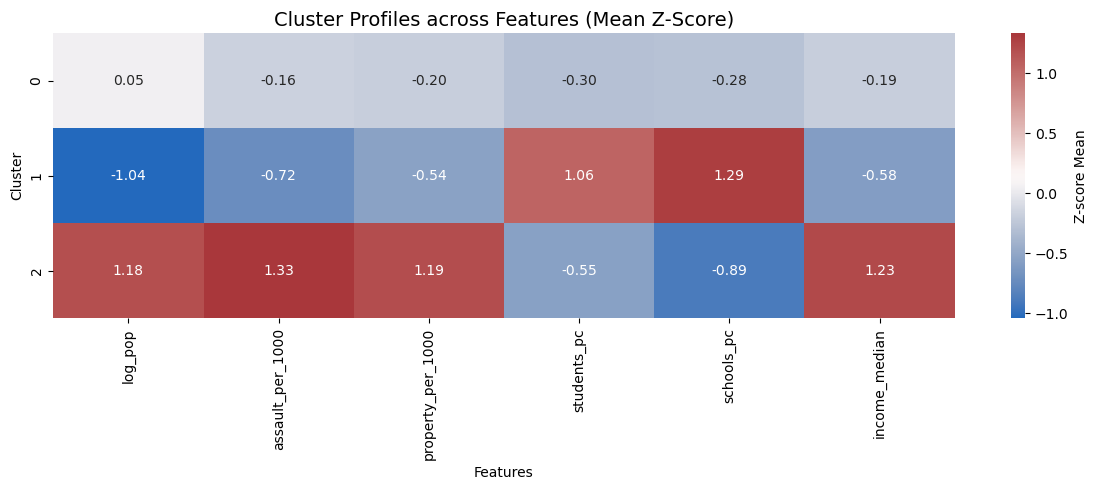

In [41]:
# heatmap of the mean scaled value (z-score) of each feature in each cluster.
# the scaled values put all features on the same scale, so the colours can be compared across features.
# Above 0 means the cluster is above the average district for that feature, below 0 means below it.
scaled_with_clusters = pd.DataFrame(scaled_cluster_features, columns=cluster_features, index=districts_2022.index)
scaled_with_clusters['cluster'] = districts_2022['cluster']

cluster_profiles = scaled_with_clusters.groupby('cluster').mean()

plt.figure(figsize=(12, 5))
sns.heatmap(
    cluster_profiles,
    annot=True,
    cmap='vlag',
    fmt='.2f',
    cbar_kws={'label': 'Z-score Mean'}
)
plt.title('Cluster Profiles across Features (Mean Z-Score)', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

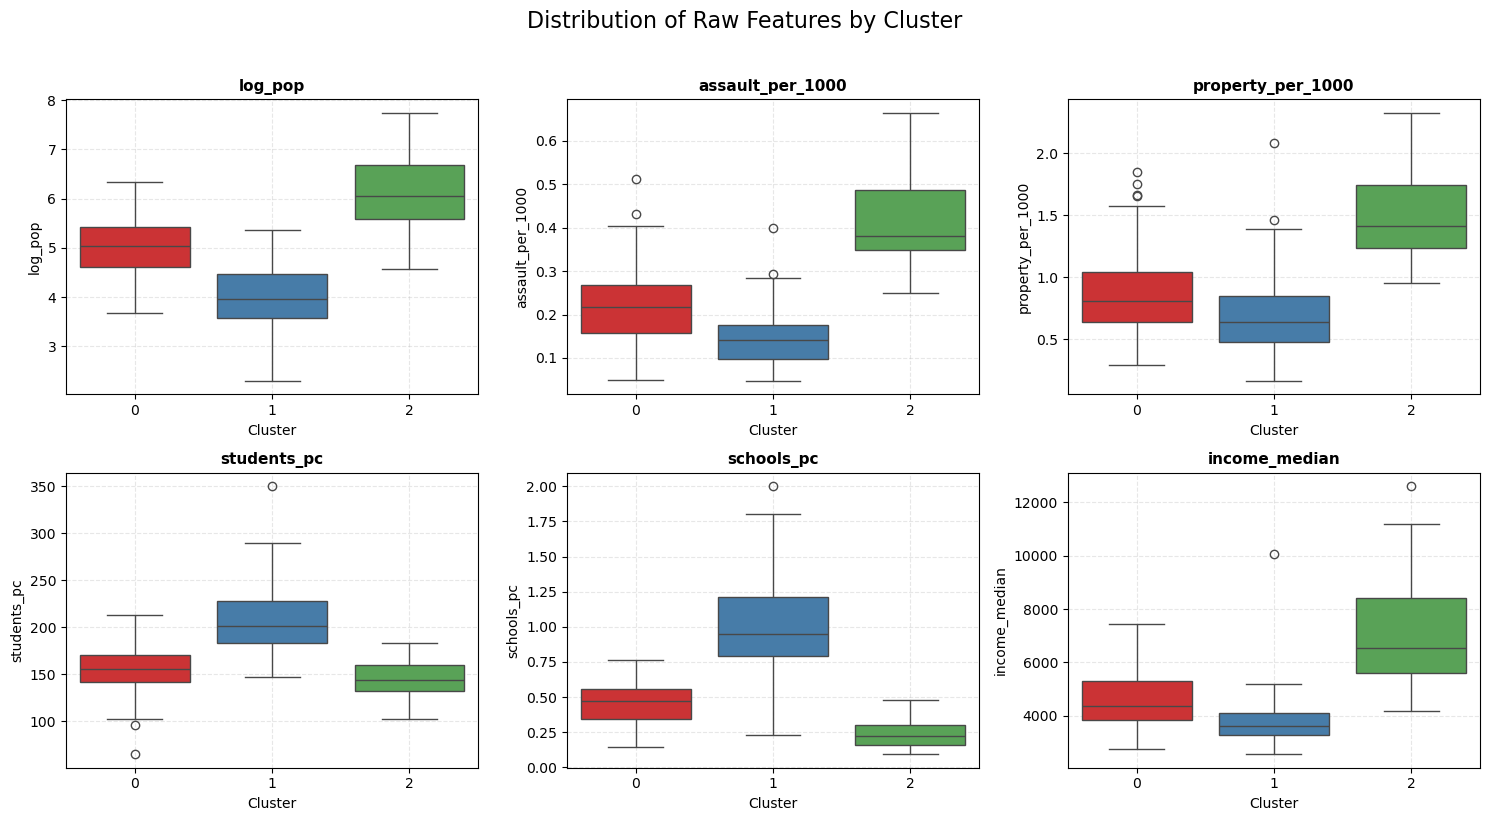

In [42]:
# one box plot per feature, showing the spread of the raw (unscaled) values in each cluster.
# the means in the heatmap do not show how spread out each cluster is or whether it has outliers.
import math

grid_columns = 3
grid_rows = math.ceil(len(cluster_features) / grid_columns)
fig, axes = plt.subplots(grid_rows, grid_columns, figsize=(15, 4 * grid_rows))
# flatten turns the 2D grid of axes into a flat list, so each plot can be picked with one index
axes = axes.flatten()

for plot_index, feature_name in enumerate(cluster_features):
    sns.boxplot(
        data=districts_2022,
        x='cluster',
        y=feature_name,
        ax=axes[plot_index],
        palette='Set1',
        hue='cluster',
        legend=False
    )
    axes[plot_index].set_title(feature_name, fontsize=11, fontweight='bold')
    axes[plot_index].set_xlabel('Cluster')
    axes[plot_index].grid(True, linestyle='--', alpha=0.3)

# hides the empty plots left over when the features do not fill the whole grid
for unused_axis in axes[len(cluster_features):]:
    unused_axis.set_visible(False)

plt.suptitle('Distribution of Raw Features by Cluster', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Initial k-means with k=4, with these feats = ['log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median',
         'poverty_relative', 'gini', 'piped_water', 'electricity'] results in low sillouhette values even as, and the feature distribution graph shows a lot of outliers for piped water and electricity

![iter_1_cluster]("./img/cluster_1.png")

![iter_1_elbow]("./img/elbow_1.png")

![iter_1_box]("img/box_plots_1.png")

in the next iteration we would use ['log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median']to see if we can get better sillouhettes

the second iteration shows that we managed to get a lower inertia 401.309793, higher sillhouette 0.269467, at k=3. we will use this as our training baseline for logistic regression. We will train the data on 2022 and test on other years

# creating the dataframes

In [43]:
# keeps the district name and the six clustering columns for 2022.
# the 2023 and 2024 tables below have the same columns, so values can be compared and copied between years.
districts_2022_selected = districts_2022.copy()
districts_2022_selected = districts_2022_selected[['district', 'log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median']]

In [44]:
# builds the 2023 table with the same derived columns as 2022.
districts_2023 = df_district[df_district['year'] == 2023].copy()
# population is in thousands, so crimes / population is crimes per 1,000 people
districts_2023['assault_per_1000'] = districts_2023['crimes_assault'] / districts_2023['population']
districts_2023['property_per_1000'] = districts_2023['crimes_property'] / districts_2023['population']
districts_2023['students_pc'] = (districts_2023['students_primary'] + districts_2023['students_secondary']) / districts_2023['population']
districts_2023['schools_pc'] = (districts_2023['schools_primary'] + districts_2023['schools_secondary']) / districts_2023['population']
districts_2023['log_pop'] = np.log(districts_2023['population'])

# keeps the same columns as the 2022 table
districts_2023 = districts_2023[['district', 'log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median']]

In [45]:
# builds the 2024 table in the same way. 2024 is the year the final model predicts.
target_year = 2024
target_year_rows = df_district[df_district['year'] == target_year].copy()
# population is in thousands, so crimes / population is crimes per 1,000 people
target_year_rows['assault_per_1000'] = target_year_rows['crimes_assault'] / target_year_rows['population']
target_year_rows['property_per_1000'] = target_year_rows['crimes_property'] / target_year_rows['population']
target_year_rows['students_pc'] = (target_year_rows['students_primary'] + target_year_rows['students_secondary']) / target_year_rows['population']
target_year_rows['schools_pc'] = (target_year_rows['schools_primary'] + target_year_rows['schools_secondary']) / target_year_rows['population']
target_year_rows['log_pop'] = np.log(target_year_rows['population'])
# keeps the same columns as the 2022 table
districts_2024 = target_year_rows[['district', 'log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median']]

In [46]:
# column types and non-missing counts for 2022
districts_2022_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 6 to 1306
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   district           131 non-null    object 
 1   log_pop            131 non-null    float64
 2   assault_per_1000   131 non-null    float64
 3   property_per_1000  131 non-null    float64
 4   students_pc        131 non-null    float64
 5   schools_pc         131 non-null    float64
 6   income_median      131 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.2+ KB


In [47]:
# missing values per column in 2023
districts_2023.isnull().sum()

district               0
log_pop                0
assault_per_1000       0
property_per_1000      0
students_pc            1
schools_pc             0
income_median        131
dtype: int64

In [48]:
# column types and non-missing counts for 2023
districts_2023.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 7 to 1307
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   district           131 non-null    object 
 1   log_pop            131 non-null    float64
 2   assault_per_1000   131 non-null    float64
 3   property_per_1000  131 non-null    float64
 4   students_pc        130 non-null    float64
 5   schools_pc         131 non-null    float64
 6   income_median      0 non-null      float64
dtypes: float64(6), object(1)
memory usage: 8.2+ KB


In [49]:
# 2023 rows with no students_pc value
districts_2023[districts_2023['students_pc'].isna()]

,district,log_pop,assault_per_1000,property_per_1000,students_pc,schools_pc,income_median
547,Kampar,4.594109,0.111223,0.808898,NaN,0.465116,NaN


In [50]:
# 2024 rows with no students_pc value
districts_2024[districts_2024['students_pc'].isna()]

,district,log_pop,assault_per_1000,property_per_1000,students_pc,schools_pc,income_median
548,Kampar,4.60417,NaN,NaN,NaN,0.46046,4538.0


In [51]:
# fills Kampar's missing values:
# - 2023 students_pc is copied from 2022
# - 2024 assault_per_1000, property_per_1000 and students_pc are copied from 2023
# Kampar has no enrolment data after 2022 (see the Perak year coverage table above), and students_pc is a
# model feature in 2023 and 2024. The value from the nearest earlier year is used.
# .values copies the numbers only, so the different row indexes of the two tables do not matter.
columns_to_fill = ['assault_per_1000', 'property_per_1000', 'students_pc']
district_to_fill = 'Kampar'

districts_2023.loc[districts_2023['district'] == district_to_fill, 'students_pc'] = districts_2022_selected.loc[districts_2022_selected['district'] == district_to_fill, 'students_pc'].values
districts_2024.loc[districts_2024['district'] == district_to_fill, columns_to_fill] = districts_2023.loc[districts_2023['district'] == district_to_fill, columns_to_fill].values

In [52]:
# districts_2023.isnull().sum()
# districts_2024.isnull().sum()
# missing values per column in 2023 after the Kampar fill
districts_2023.isnull().sum()

district               0
log_pop                0
assault_per_1000       0
property_per_1000      0
students_pc            0
schools_pc             0
income_median        131
dtype: int64

In [53]:
# fills 2023 median income with the geometric mean of the same district's 2022 and 2024 values.
# there is no income survey for 2023, and 2023 lies between the 2022 and 2024 surveys. The geometric mean
# sqrt(2022 value x 2024 value) is the 2023 value if income grows by the same percentage each year.
# Because the 2024 value is used, the 2023 test features contain information from the following year.
# The cross-sectional section at the end uses 2022 features only and does not use this fill.
income_2022_by_district = districts_2022_selected.set_index('district')['income_median']
income_2024_by_district = districts_2024.set_index('district')['income_median']

# map looks up each 2023 district in the 2022 and 2024 series; a district with no 2024 value gives NaN
districts_2023['income_median'] = np.sqrt(districts_2023['district'].map(income_2022_by_district) * districts_2023['district'].map(income_2024_by_district))

In [54]:
# missing values per column in 2023 after the income fill
districts_2023.isnull().sum()

district             0
log_pop              0
assault_per_1000     0
property_per_1000    0
students_pc          0
schools_pc           0
income_median        4
dtype: int64

In [55]:
# 2023 rows still missing median income (these have no 2024 survey value)
districts_2023[districts_2023['income_median'].isna()]

,district,log_pop,assault_per_1000,property_per_1000,students_pc,schools_pc,income_median
297,Kuala Lumpur,7.603748,0.463679,1.764970,110.579847,0.145585,NaN
307,Labuan,4.595120,0.191919,1.101010,172.949495,0.282828,NaN
627,Perlis,5.680514,0.255885,0.900716,149.904469,0.354828,NaN
687,Putrajaya,4.777441,0.084175,0.505051,301.750842,0.227273,NaN


In [56]:
# 2024 rows missing median income
districts_2024[districts_2024['income_median'].isna()]

,district,log_pop,assault_per_1000,property_per_1000,students_pc,schools_pc,income_median
298,Kuala Lumpur,7.634095,NaN,NaN,108.441596,0.140750,NaN
308,Labuan,4.613138,NaN,NaN,174.742063,0.277778,NaN
628,Perlis,5.693059,NaN,NaN,151.688005,0.350404,NaN
688,Putrajaya,4.789989,NaN,NaN,313.316708,0.224439,NaN


In [57]:
# 2022 rows missing median income (none expected, 2022 is a survey year)
districts_2022_selected[districts_2022_selected['income_median'].isna()]

,district,log_pop,assault_per_1000,property_per_1000,students_pc,schools_pc,income_median


# # # some of the districts have no data for income_median for 2024, therefore we need to do some investigation whether linear interpolation would be appropriate

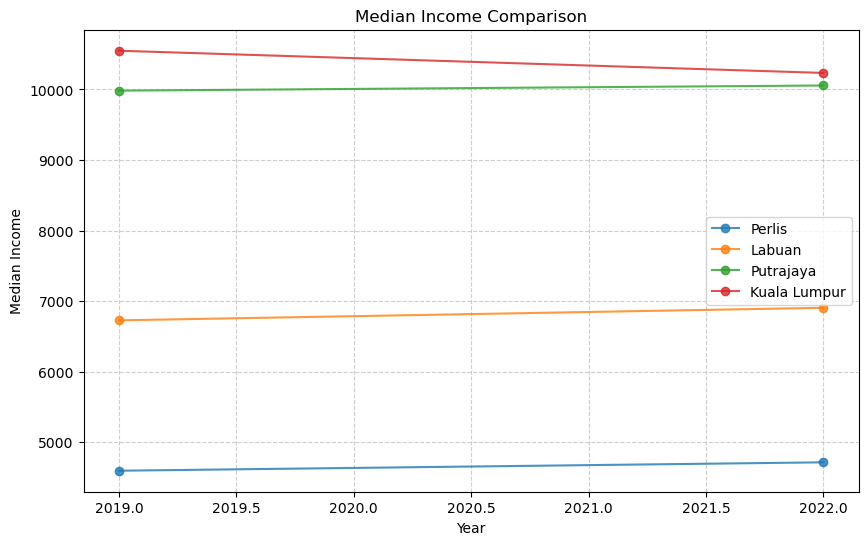

--- R² Values ---
Only 2 points for Perlis. Total growth: 2.6%
Only 2 points for Labuan. Total growth: 2.6%
Only 2 points for Putrajaya. Total growth: 0.7%
Only 2 points for Kuala Lumpur. Total growth: -3.0%
--- Extrapolating Missing Data Forwards ---
state          Perlis       Labuan     Putrajaya  Kuala Lumpur
district       Perlis       Labuan     Putrajaya  Kuala Lumpur
year                                                          
2016              NaN          NaN           NaN           NaN
2017              NaN          NaN           NaN           NaN
2018              NaN          NaN           NaN           NaN
2019      4594.000000  6726.000000   9983.000000  10549.000000
2020      4633.329012  6784.817487  10007.274261  10442.937187
2021      4672.994718  6844.149321  10031.607547  10337.940760
2022      4713.000000  6904.000000  10056.000000  10234.000000
2023      4753.347765  6964.374061  10080.451765  10131.104291
2024      4794.040946  7025.276080  10104.962986  10029

In [58]:
# for Perlis and the three federal territories (Labuan, Putrajaya, Kuala Lumpur), which have no 2024 income survey:
# 1) plots median income for the years that have data
# 2) prints the R² of a straight-line fit (3 or more points) or the total growth (2 points)
# 3) fills the empty years after the first survey: compound annual growth for 2 points,
# a straight-line trend for 3 or more points
# these places need 2023 and 2024 values for the model. With only two surveys (2019 and 2022) a straight-line fit
# cannot be checked, so the yearly growth rate between the two surveys is continued forward.
import matplotlib.pyplot as plt
from scipy.stats import linregress

# rows: year, columns: (state, district), values: median income
income_by_year = df_district.pivot(index='year', columns=['state', 'district'], values='income_median')

# the (state, district) pairs to check
target_places = [
    ('Perlis', 'Perlis'),
    ('Labuan', 'Labuan'),
    ('Putrajaya', 'Putrajaya'),
    ('Kuala Lumpur', 'Kuala Lumpur')
]

income_selected = income_by_year[target_places]

fig, ax = plt.subplots(figsize=(10, 6))

for place in income_selected.columns:
    state, district = place
    # missing years are dropped for each place separately, so each line only joins the years that have data
    known_income = income_selected[place].dropna()
    ax.plot(known_income.index, known_income.values, marker='o', alpha=0.8, label=district)

ax.set_title('Median Income Comparison')
ax.set_xlabel('Year')
ax.set_ylabel('Median Income')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()  # shows which colour belongs to which district
plt.show()

print("--- R² Values ---")
for place in income_selected.columns:
    state, district = place
    known_income = income_selected[place].dropna()

    if len(known_income) >= 3:
        r2_value = linregress(known_income.index, known_income.values).rvalue ** 2
        print(f"R² for {district}: {r2_value:.4f}")
    elif len(known_income) == 2:
        # percentage growth between the two available years
        start_value = known_income.iloc[0]
        end_value = known_income.iloc[-1]
        growth = ((end_value - start_value) / start_value) * 100
        print(f"Only 2 points for {district}. Total growth: {growth:.1f}%")
    else:
        print(f"Insufficient data for {district} (less than 2 points).")

# adds a row for every year from the first to the last year, so the missing years exist as empty rows to fill
min_year = income_selected.index.min()
max_year = income_selected.index.max()
income_selected = income_selected.reindex(range(min_year, max_year + 1))

print("--- Extrapolating Missing Data Forwards ---")
for place in income_selected.columns:
    state, district = place
    known_income = income_selected[place].dropna()

    if len(known_income) == 2:
        year_start, year_end = known_income.index[0], known_income.index[-1]
        value_start, value_end = known_income.iloc[0], known_income.iloc[-1]

        # compound annual growth rate: the yearly growth that turns value_start into value_end
        years_between = year_end - year_start
        annual_growth = (value_end / value_start) ** (1 / years_between) - 1

        # fills every empty year from the year after the first survey up to max_year
        for year_to_fill in range(year_start + 1, max_year + 1):
            if pd.isna(income_selected.at[year_to_fill, place]):  # only empty rows are filled
                years_passed = year_to_fill - year_start
                estimated_value = value_start * ((1 + annual_growth) ** years_passed)
                income_selected.at[year_to_fill, place] = estimated_value

    elif len(known_income) >= 3:
        # 'slinear' with fill_value='extrapolate' continues the straight line past the last known year
        income_selected[place] = income_selected[place].interpolate(
            method='slinear',
            fill_value='extrapolate',
            limit_direction='forward'
        )
        print(f"Filled {district} forwards using linear trendline.")

    else:
        print(f"Skipping {district}: Insufficient data.")
# the filled table; the 2023 and 2024 values are copied into the cells below
print(income_selected)

In [59]:
# sets Perlis' 2023 median income to the extrapolated value from the table above
is_perlis = (districts_2023['district'] == 'Perlis')
districts_2023.loc[is_perlis, 'income_median'] = 4753.347765

In [60]:
# sets Kuala Lumpur's 2023 median income to the extrapolated value from the table above
is_kuala_lumpur = (districts_2023['district'] == 'Kuala Lumpur')
districts_2023.loc[is_kuala_lumpur, 'income_median'] = 10131.104291

In [61]:
# sets Putrajaya's 2023 median income to the extrapolated value from the table above
is_putrajaya = (districts_2023['district'] == 'Putrajaya')
districts_2023.loc[is_putrajaya, 'income_median'] = 10080.451765

In [62]:
# sets Labuan's 2023 median income to the extrapolated value from the table above
is_labuan = (districts_2023['district'] == 'Labuan')
districts_2023.loc[is_labuan, 'income_median'] = 6964.374061

In [63]:
# missing values per column in 2023 (should all be 0 now)
districts_2023.isnull().sum()

district             0
log_pop              0
assault_per_1000     0
property_per_1000    0
students_pc          0
schools_pc           0
income_median        0
dtype: int64

In [64]:
# missing values per column in 2024
districts_2024.isnull().sum()

district               0
log_pop                0
assault_per_1000     130
property_per_1000    130
students_pc            0
schools_pc             0
income_median          4
dtype: int64

In [65]:
# sets Perlis' 2024 median income to the extrapolated value from the table above
is_perlis = (districts_2024['district'] == 'Perlis')
districts_2024.loc[is_perlis, 'income_median'] = 4794.040946

In [66]:
# sets Kuala Lumpur's 2024 median income to the extrapolated value from the table above
is_kuala_lumpur = (districts_2024['district'] == 'Kuala Lumpur')
districts_2024.loc[is_kuala_lumpur, 'income_median'] = 10029.243127

In [67]:
# sets Labuan's 2024 median income to the extrapolated value from the table above
is_labuan = (districts_2024['district'] == 'Labuan')
districts_2024.loc[is_labuan, 'income_median'] = 7025.276080

In [68]:
# sets Putrajaya's 2024 median income to the extrapolated value from the table above
is_putrajaya = (districts_2024['district'] == 'Putrajaya')
districts_2024.loc[is_putrajaya, 'income_median'] = 10104.962986

In [69]:
# missing values per column in 2024 after the income fill
districts_2024.isnull().sum()

district               0
log_pop                0
assault_per_1000     130
property_per_1000    130
students_pc            0
schools_pc             0
income_median          0
dtype: int64

In [70]:
# 2024 rows with no crime rate: crime data ends in 2023, so every district except Kampar (filled above) is missing
districts_2024[districts_2024['assault_per_1000'].isna()]

,district,log_pop,assault_per_1000,property_per_1000,students_pc,schools_pc,income_median
8,Batu Pahat,6.234607,NaN,NaN,121.662419,0.343070,7555.000000
18,Johor Bahru,7.495042,NaN,NaN,136.281474,0.150631,8977.000000
28,Kluang,5.810242,NaN,NaN,134.788732,0.350614,6158.000000
38,Kota Tinggi,5.453182,NaN,NaN,147.738758,0.471092,6284.000000
48,Kulai,5.861641,NaN,NaN,162.943353,0.145175,8406.000000
...,...,...,...,...,...,...,...
1268,Hulu Terengganu,4.312141,NaN,NaN,218.538874,0.884718,6134.000000
1278,Kemaman,5.445443,NaN,NaN,181.113509,0.310747,7709.000000
1288,Kuala Terengganu,5.993712,NaN,NaN,191.539037,0.304315,6882.763033
1298,Marang,4.841822,NaN,NaN,180.812944,0.331492,6246.000000


In [71]:
# fits two regression models on 2022 and tests them on 2023 (the same districts, one year later).
# - features: log population, students and schools per 1,000 people, median income
# - targets: assault and property crimes per 1,000 people (one model predicts both)
# - linear: StandardScaler + LinearRegression
# - random_forest: 300 decision trees, each fitted on a random sample of the rows (drawn with replacement);
# the prediction is the average of the trees
# Reports R2 (share of the variation explained), MAE (mean absolute error), RMSE (root mean squared error,
# which gives more weight to large errors) and the mean actual 2023 rate for reference.
# the crime columns are not used as features because they are the values being predicted.
# The asserts stop the cell if a feature or target still has a missing value, since these models cannot use NaN.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model_features = ['log_pop', 'students_pc', 'schools_pc', 'income_median']
target_columns = ['assault_per_1000', 'property_per_1000']

assert not districts_2023[model_features + target_columns].isna().any().any()
assert not districts_2024[model_features].isna().any().any()

regression_models = {
    'linear': make_pipeline(StandardScaler(), LinearRegression()),
    'random_forest': RandomForestRegressor(n_estimators=300, random_state=0),
}

# evaluation: train on 2022, test on 2023
evaluation_rows = []
for model_name, model in regression_models.items():
    model.fit(districts_2022[model_features], districts_2022[target_columns])
    predictions_2023 = model.predict(districts_2023[model_features])
    # predictions_2023 has one column per target, in the same order as target_columns
    for target_index, target_name in enumerate(target_columns):
        evaluation_rows.append({'model': model_name, 'target': target_name,
                                'R2': r2_score(districts_2023[target_name], predictions_2023[:, target_index]),
                                'MAE': mean_absolute_error(districts_2023[target_name], predictions_2023[:, target_index]),
                                'RMSE': mean_squared_error(districts_2023[target_name], predictions_2023[:, target_index]) ** 0.5,
                                'mean_actual_2023': districts_2023[target_name].mean()})
pd.DataFrame(evaluation_rows).round(3)

,model,target,R2,MAE,RMSE,mean_actual_2023
0,linear,assault_per_1000,0.117,0.089,0.121,0.245
1,linear,property_per_1000,0.181,0.306,0.401,1.012
2,random_forest,assault_per_1000,0.366,0.074,0.102,0.245
3,random_forest,property_per_1000,0.566,0.227,0.292,1.012


# # Check: what the 2022 → 2023 score measures

The cell above trains on 2022 and tests on 2023 for the same 131 districts. The next two cells compare that score with a simple baseline and check how close the random forest's 2023 predictions are to each district's own 2022 rate.

In [72]:
# the test set has the same districts as the training set, one year later. Crime rates change little
# between years, so a useful reference is a baseline that predicts each district's 2023 rate as its 2022 rate.
# If the model scores below this baseline, the features add nothing beyond last year's value.
# joins the 2022 and 2023 rates by district and computes R2 when the 2022 rate is used as the 2023 prediction.
rates_2022_and_2023 = districts_2022[['district'] + target_columns].merge(districts_2023[['district'] + target_columns], on='district', suffixes=('_2022', '_2023'))
for target_name in target_columns:
    print(target_name, 'R2 using the 2022 rate as the 2023 prediction:', r2_score(rates_2022_and_2023[target_name + '_2023'], rates_2022_and_2023[target_name + '_2022']))

assault_per_1000 R2 using the 2022 rate as the 2023 prediction: 0.4750261096173417
property_per_1000 R2 using the 2022 rate as the 2023 prediction: 0.7939040741813002


In [73]:
# the features hardly change between 2022 and 2023. A random forest with default settings (leaves of 1 row)
# fits each 2022 district closely, so for nearly identical 2023 features its output is close to that
# district's 2022 rate. If so, the 2023 score reflects how stable crime rates are, not how well the features
# explain crime.
# 1) correlation of each feature between 2022 and 2023, across districts
# 2) R2 between the random forest's 2023 predictions and each district's own 2022 rate
# (a high value means the predictions mostly reproduce last year's rate)
model_inputs_2022 = districts_2022.set_index('district')[model_features]
model_inputs_2023 = districts_2023.set_index('district')[model_features]
print(model_inputs_2022.corrwith(model_inputs_2023))

forest_predictions_2023 = pd.DataFrame(regression_models['random_forest'].predict(districts_2023[model_features]), columns=target_columns, index=districts_2023['district'])
actual_rates_2022 = districts_2022.set_index('district')[target_columns]
for target_name in target_columns:
    # .loc puts the predictions in the same district order as the 2022 rates before comparing them
    print(target_name, 'R2 of 2023 predictions vs own 2022 rate:', r2_score(actual_rates_2022[target_name], forest_predictions_2023.loc[actual_rates_2022.index, target_name]))

log_pop          0.999836
students_pc      0.955975
schools_pc       0.999804
income_median    0.993093
dtype: float64
assault_per_1000 R2 of 2023 predictions vs own 2022 rate: 0.6742152116247704
property_per_1000 R2 of 2023 predictions vs own 2022 rate: 0.6314041900523075


In [74]:
# final model: a random forest fitted on 2022 and 2023 together, then used to predict 2024.
# 2022 and 2023 are the two years prepared above with all features and crime rates filled, so both are used
# for training. Stacking them gives twice as many rows as one year.
training_rows = pd.concat([districts_2022[model_features + target_columns], districts_2023[model_features + target_columns]], ignore_index=True)
final_model = RandomForestRegressor(n_estimators=300, random_state=0)
final_model.fit(training_rows[model_features], training_rows[target_columns])

districts_2024[['pred_assault_per_1000', 'pred_property_per_1000']] = final_model.predict(districts_2024[model_features])
districts_2024[['district', 'pred_assault_per_1000', 'pred_property_per_1000']]

/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_17274/2654175092.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  districts_2024[['pred_assault_per_1000', 'pred_property_per_1000']] = final_model.predict(districts_2024[model_features])
/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_17274/2654175092.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  districts_2024[['pred_assault_per_1000', 'pred_property_per_1000']] = final_model.predict(districts_2024[model_features])


,district,pred_assault_per_1000,pred_property_per_1000
8,Batu Pahat,0.321774,1.537886
18,Johor Bahru,0.420791,1.457413
28,Kluang,0.203914,0.816957
38,Kota Tinggi,0.206892,0.899015
48,Kulai,0.376944,1.431107
...,...,...,...
1268,Hulu Terengganu,0.233821,0.986974
1278,Kemaman,0.267824,1.171242
1288,Kuala Terengganu,0.247197,1.125180
1298,Marang,0.212337,0.969554


In [75]:
# saves the final model to crime_model.joblib for the Streamlit app (run after the 2024 prediction cell).
# Besides the model, the file stores the feature and target names, and the min, median and max of each
# feature in the training rows.
# the app loads this file instead of fitting the model again, so the file holds what the app reads:
# the fitted model, the feature names in the order the model expects, and the feature ranges.
import joblib

joblib.dump({
    'model': final_model,
    'features': model_features,
    'targets': target_columns,
    'ranges': training_rows[model_features].agg(['min', 'median', 'max']).to_dict(),
}, 'crime_model.joblib')

['crime_model.joblib']

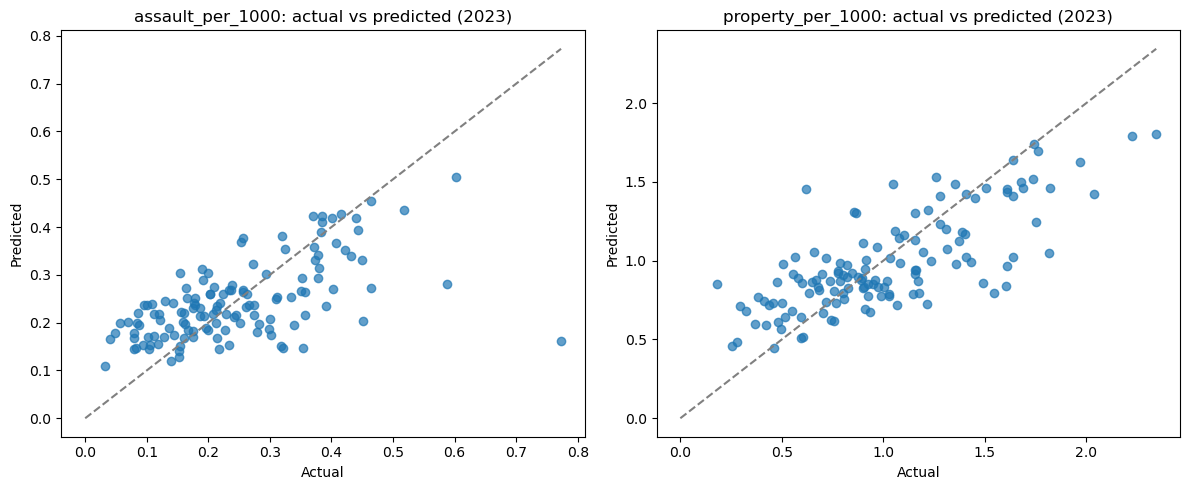

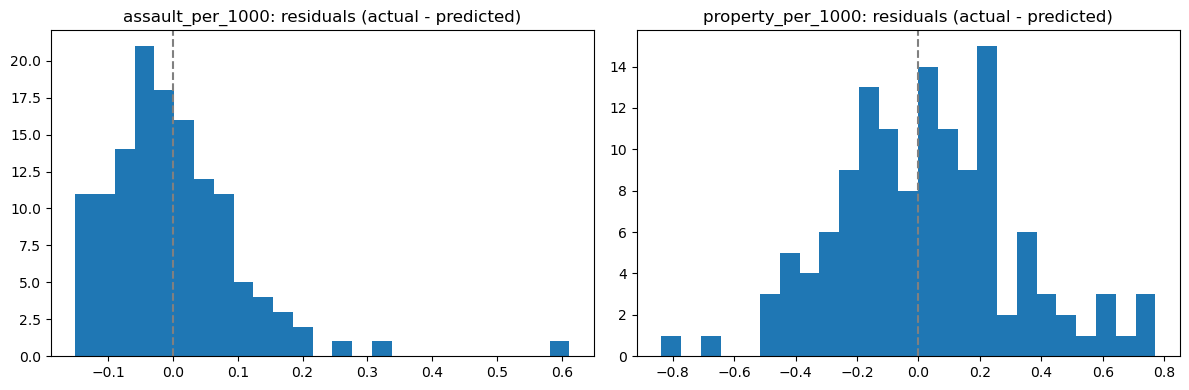

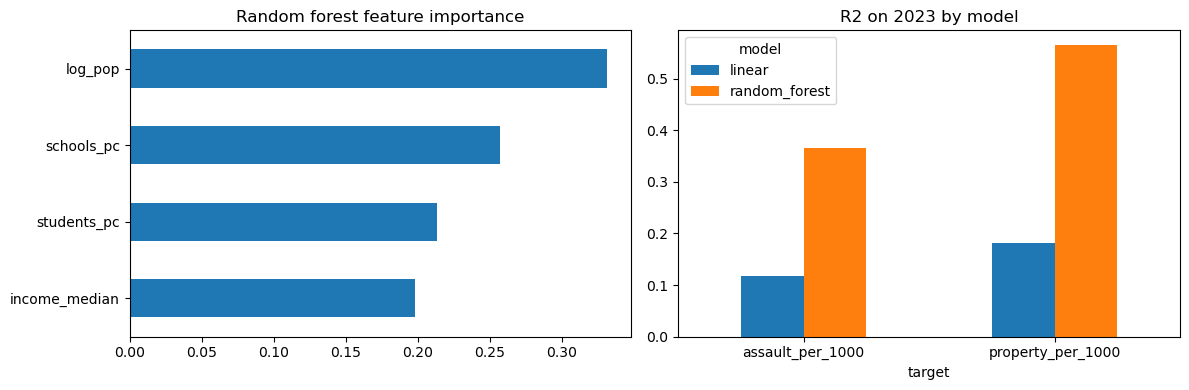

In [76]:
# plots for the 2022 -> 2023 evaluation (run after the evaluation and final model cells):
# 1) actual vs predicted 2023 rates for the random forest; points on the dashed line are exact predictions
# 2) residuals (actual - predicted); a histogram centred on 0 means no overall over- or under-prediction
# 3) random forest feature importance (how much each feature reduces the error in the trees' splits),
# and the R2 of both models side by side
forest_model = regression_models['random_forest']
forest_prediction_array = forest_model.predict(districts_2023[model_features])
evaluation_results = pd.DataFrame(evaluation_rows)

# 1. actual vs predicted, 2023 test set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for target_index, target_name in enumerate(target_columns):
    axes[target_index].scatter(districts_2023[target_name], forest_prediction_array[:, target_index], alpha=0.7)
    # the dashed line runs from 0 to the largest actual or predicted value
    axis_limit = max(districts_2023[target_name].max(), forest_prediction_array[:, target_index].max())
    axes[target_index].plot([0, axis_limit], [0, axis_limit], linestyle='--', color='grey')
    axes[target_index].set_title(f'{target_name}: actual vs predicted (2023)')
    axes[target_index].set_xlabel('Actual')
    axes[target_index].set_ylabel('Predicted')
plt.tight_layout()
plt.show()

# 2. residuals, 2023 test set
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for target_index, target_name in enumerate(target_columns):
    axes[target_index].hist(districts_2023[target_name] - forest_prediction_array[:, target_index], bins=25)
    axes[target_index].axvline(0, color='grey', linestyle='--')
    axes[target_index].set_title(f'{target_name}: residuals (actual - predicted)')
plt.tight_layout()
plt.show()

# 3. feature importance and model comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(forest_model.feature_importances_, index=model_features).sort_values().plot.barh(ax=axes[0])
axes[0].set_title('Random forest feature importance')
evaluation_results.pivot(index='target', columns='model', values='R2').plot.bar(ax=axes[1], rot=0)
axes[1].set_title('R2 on 2023 by model')
plt.tight_layout()
plt.show()

# Cross-sectional model: 2020–2023 average crime rate

This section predicts crime rates for districts the model has not seen, instead of next year's rate for the same districts.

- Target: crimes per 1,000 people averaged over 2020–2023 (total crimes / total population per district).
- Features: 2022 values. 2022 is the only year where all eight datasets have data.
- Evaluation: 5-fold cross-validation over districts, repeated 10 times with different shuffles.

In [77]:
# the population file has age and sex breakdowns, but the join above keeps only age == 'overall'.
# Age structure (for example the share of young men) is a common feature in crime studies.
# from the cleaned population table (ethnicity == 'overall'), computes per district and year:
# - young_male_share: males aged 15-29 / total population
# - age65_share: people aged 65 and over / total population
# - male_share: males / total population
# Dividing two series matches their rows by the (state, district, year) index.
population_detail = prepare_for_join(clean_tables['population'])
population_detail = population_detail[population_detail['ethnicity'] == 'overall']
population_total = population_detail[(population_detail['sex'] == 'both') & (population_detail['age'] == 'overall')].set_index(join_keys)['population']
young_male_count = population_detail[(population_detail['sex'] == 'male') & population_detail['age'].isin(['15-19', '20-24', '25-29'])].groupby(join_keys)['population'].sum()
age65_count = population_detail[(population_detail['sex'] == 'both') & population_detail['age'].isin(['65-69', '70-74', '75-79', '80-84', '85+'])].groupby(join_keys)['population'].sum()
male_count = population_detail[(population_detail['sex'] == 'male') & (population_detail['age'] == 'overall')].set_index(join_keys)['population']

demographic_shares = pd.DataFrame({
    'young_male_share': young_male_count / population_total,
    'age65_share': age65_count / population_total,
    'male_share': male_count / population_total,
}).reset_index()
demographic_shares.describe()

,year,young_male_share,age65_share,male_share
count,786.000000,786.000000,786.000000,786.000000
mean,2022.500000,0.143710,0.074194,0.520455
std,1.708913,0.019952,0.020312,0.017133
min,2020.000000,0.072344,0.014652,0.478205
25%,2021.000000,0.130833,0.062871,0.509287
50%,2022.500000,0.143295,0.071961,0.518035
75%,2024.000000,0.153149,0.084440,0.531613
max,2025.000000,0.234801,0.158537,0.604911


In [78]:
# the earlier cells compute the derived columns separately for 2022, 2023 and 2024. Computing them once on
# the full table puts every year in one dataframe, which is needed to average crime over 2020-2023.
# joins the age/sex shares to df_district and adds the same derived columns as the earlier cells
# (crimes per 1,000 people, students and schools per 1,000 people, log population).
district_panel = df_district.merge(demographic_shares, on=join_keys, how='left')
district_panel['assault_per_1000'] = district_panel['crimes_assault'] / district_panel['population']
district_panel['property_per_1000'] = district_panel['crimes_property'] / district_panel['population']
district_panel['students_pc'] = (district_panel['students_primary'] + district_panel['students_secondary']) / district_panel['population']
district_panel['schools_pc'] = (district_panel['schools_primary'] + district_panel['schools_secondary']) / district_panel['population']
district_panel['log_pop'] = np.log(district_panel['population'])

In [79]:
# many districts record few assaults per year, so a one-year rate changes a lot by chance.
# This limits how well any feature set can predict a single year.
# 1) share of district-years in 2020-2023 with fewer than 20 assaults
# (the mean of a True/False column is the share of True values)
# 2) correlation of the districts' assault rates between each pair of years
panel_2020_2023 = district_panel[district_panel['year'].between(2020, 2023)]
print('share of district-years with < 20 assaults:', (panel_2020_2023['crimes_assault'] < 20).mean())
panel_2020_2023.pivot(index=['state', 'district'], columns='year', values='assault_per_1000').corr()

share of district-years with < 20 assaults: 0.37404580152671757


year,2020,2021,2022,2023
year,,,,
2020,1.000000,0.814615,0.678349,0.651511
2021,0.814615,1.000000,0.818654,0.689204
2022,0.678349,0.818654,1.000000,0.728504
2023,0.651511,0.689204,0.728504,1.000000


In [80]:
# averaging 2020-2023 reduces the year-to-year variation shown above. Features come from 2022, the survey
# year inside that range and the only year where all datasets have values.
# sanitation and electricity are left out because most districts are at 100% (see the describe output).
# - features_2022: one row per district with the 2022 features and the state
# - average_rates: total crimes / total population over 2020-2023 (per 1,000 people). Dividing the totals
# gives each year a weight by its population, instead of averaging the four yearly rates equally.
# - rates_2022: the 2022 rate, kept for comparison
# - population_weights: total population over 2020-2023, used as weights for the Poisson models
# .loc[features_2022.index] puts the rows in the same district order as features_2022.
features_2022 = district_panel[district_panel['year'] == 2022].set_index('district')
assert features_2022.index.is_unique

totals_2020_2023 = panel_2020_2023.groupby('district')[['crimes_assault', 'crimes_property', 'population']].sum()
average_rates = pd.DataFrame({
    'assault_per_1000': totals_2020_2023['crimes_assault'] / totals_2020_2023['population'],
    'property_per_1000': totals_2020_2023['crimes_property'] / totals_2020_2023['population'],
}).loc[features_2022.index]
rates_2022 = features_2022[target_columns]
population_weights = totals_2020_2023['population'].loc[features_2022.index]

socioeconomic_features = ['income_mean', 'poverty_absolute', 'poverty_relative', 'gini', 'piped_water']
demographic_features = ['young_male_share', 'age65_share', 'male_share']
all_features = model_features + socioeconomic_features + demographic_features
assert not features_2022[all_features].isna().any().any()

features_2022[['piped_water', 'sanitation', 'electricity']].describe()

,piped_water,sanitation,electricity
count,131.000000,131.000000,131.000000
mean,90.419050,99.655084,98.815369
std,14.637240,1.715391,3.349016
min,29.800000,84.150000,77.953648
25%,84.920556,100.000000,99.800000
50%,98.400000,100.000000,100.000000
75%,100.000000,100.000000,100.000000
max,100.000000,100.000000,100.000000


In [81]:
# the original evaluation is one split (2022 -> 2023) with the same districts on both sides.
# K-fold over districts keeps each test district out of training. Repeating with different shuffles
# reduces the effect of a single lucky or unlucky split, which matters with 131 rows.
# for each repeat, splits the districts into 5 folds, fits on 4 folds and predicts the 5th, then computes
# R2 over all 131 out-of-fold predictions. Returns the mean R2 over the repeats.
# - make_model is a function that returns a new, unfitted model, so every fold starts from scratch
# - log_target=True fits on log(rate) and converts the predictions back with exp
# - weights are passed to the model as sample_weight (used by the Poisson models)
from sklearn.model_selection import KFold

def cross_validated_r2(make_model, features, target, log_target=False, weights=None, n_repeats=10):
    repeat_scores = []
    for repeat_index in range(n_repeats):
        # one prediction per district, filled in fold by fold
        out_of_fold = pd.Series(np.nan, index=target.index)
        # repeat_index is the shuffle seed, so each repeat splits the districts differently
        for train_index, test_index in KFold(5, shuffle=True, random_state=repeat_index).split(features):
            model = make_model()
            train_target = np.log(target.iloc[train_index]) if log_target else target.iloc[train_index]
            fit_arguments = {}
            if weights is not None:
                # in a pipeline, sample_weight has to be addressed to the last step as '<step name>__sample_weight'
                if hasattr(model, 'steps'):
                    weight_argument = model.steps[-1][0] + '__sample_weight'
                else:
                    weight_argument = 'sample_weight'
                fit_arguments = {weight_argument: weights.iloc[train_index].values}
            model.fit(features.iloc[train_index], train_target, **fit_arguments)
            fold_predictions = model.predict(features.iloc[test_index])
            out_of_fold.iloc[test_index] = np.exp(fold_predictions) if log_target else fold_predictions
        repeat_scores.append(r2_score(target, out_of_fold))
    return np.mean(repeat_scores)

# # Single year vs averaged target

In [82]:
# checks whether the averaged target is easier to predict than one year, and whether the added features help.
# The original four features (model_features) are included for comparison.
# cross-validated R2 for 2 targets (2022 only, 2020-2023 average) x 2 feature sets x 3 models.
# - ridge: linear regression with a penalty on coefficient size, which keeps coefficients stable when
# features are correlated; RidgeCV picks the penalty strength by internal cross-validation
# - random forest uses min_samples_leaf=3 so each leaf averages at least 3 districts. In testing it scored
# slightly higher than the default (1) for both feature sets and both crime types
# The model functions return a new, unfitted model each time cross_validated_r2 calls them.
from sklearn.linear_model import RidgeCV

ridge_alphas = np.logspace(-2, 3, 30)

def make_linear():
    return make_pipeline(StandardScaler(), LinearRegression())

def make_ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=ridge_alphas))

def make_random_forest():
    return RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)

model_makers = {'linear': make_linear, 'ridge': make_ridge, 'random_forest': make_random_forest}
# the keys are the labels shown in the result table
feature_sets = {'model_feats': model_features, 'all_feats': all_features}

target_comparison_rows = []
for target_label, target_table in [('2022 only', rates_2022), ('2020-2023 avg', average_rates)]:
    for feature_set_label, feature_list in feature_sets.items():
        for target_name in target_columns:
            for model_label, make_model in model_makers.items():
                target_comparison_rows.append({'target': target_label, 'features': feature_set_label, 'crime': target_name, 'model': model_label,
                                               'cv_R2': cross_validated_r2(make_model, features_2022[feature_list], target_table[target_name])})
pd.DataFrame(target_comparison_rows).pivot_table(index=['crime', 'features', 'target'], columns='model', values='cv_R2')

model                                          linear  random_forest     ridge
crime             features    target                                          
assault_per_1000  all_feats   2020-2023 avg  0.292058       0.380231  0.335739
                              2022 only      0.211440       0.349110  0.254383
                  model_feats 2020-2023 avg  0.242587       0.194316  0.224877
                              2022 only      0.152361       0.092313  0.152518
property_per_1000 all_feats   2020-2023 avg  0.209775       0.285875  0.261941
                              2022 only      0.192093       0.235343  0.220325
                  model_feats 2020-2023 avg  0.220307       0.211568  0.221577
                              2022 only      0.141972       0.146267  0.143132

# # Model comparison (2020–2023 average target)

In [83]:
# compares model types on the averaged target with all_features, with and without state. State is added to
# capture differences shared by all districts in a state that the other features do not cover (for example
# policing and reporting practices, or Sabah/Sarawak vs the Peninsula).
# - make_state_encoder(): turns 'state' into 0/1 columns and passes the other columns through unchanged.
# handle_unknown='ignore' is needed because states with one district (Kuala Lumpur, Labuan, Perlis,
# Putrajaya) are missing from the training folds when that district is in the test fold.
# - lasso: linear regression with a penalty that can set coefficients to 0
# - poisson_glm: Poisson regression on the rate with population as sample_weight, which is equivalent to
# modelling crime counts with population as exposure. alpha=0.01 is a small L2 penalty
# - extra_trees and gradient_boosting: other tree ensembles (gradient boosting with depth 3, as the data is small)
# - log target: fits on log(rate) to reduce the pull of the few high-rate districts
# The R2 here counts each district once, while the Poisson models are fitted with population weights,
# so those models give large districts more weight than the score does.
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LassoCV, PoissonRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor

def make_state_encoder():
    return make_column_transformer((OneHotEncoder(handle_unknown='ignore'), ['state']),
                                   remainder='passthrough', sparse_threshold=0)

def make_ridge_with_state():
    return make_pipeline(make_state_encoder(), StandardScaler(), RidgeCV(alphas=ridge_alphas))

def make_extra_trees():
    return ExtraTreesRegressor(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)

def make_gradient_boosting():
    return HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=10, random_state=0)

def make_poisson_gradient_boosting():
    return HistGradientBoostingRegressor(loss='poisson', max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=10, random_state=0)

def make_poisson_glm():
    return make_pipeline(StandardScaler(), PoissonRegressor(alpha=0.01, max_iter=1000))

def make_lasso_with_state():
    return make_pipeline(make_state_encoder(), StandardScaler(), LassoCV(cv=5, max_iter=20000))

def make_poisson_glm_with_state():
    return make_pipeline(make_state_encoder(), StandardScaler(), PoissonRegressor(alpha=0.01, max_iter=1000))

def make_random_forest_with_state():
    return make_pipeline(make_state_encoder(), RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1))

model_specs = [
    # label, function that builds the model, include state, extra arguments for cross_validated_r2
    ('linear', make_linear, False, {}),
    ('ridge', make_ridge, False, {}),
    ('ridge, log target', make_ridge, False, {'log_target': True}),
    ('random_forest', make_random_forest, False, {}),
    ('random_forest, log target', make_random_forest, False, {'log_target': True}),
    ('extra_trees', make_extra_trees, False, {}),
    ('gradient_boosting', make_gradient_boosting, False, {}),
    ('gradient_boosting, poisson', make_poisson_gradient_boosting, False, {'weights': population_weights}),
    ('poisson_glm', make_poisson_glm, False, {'weights': population_weights}),
    ('ridge + state', make_ridge_with_state, True, {}),
    ('ridge + state, log target', make_ridge_with_state, True, {'log_target': True}),
    ('lasso + state', make_lasso_with_state, True, {}),
    ('poisson_glm + state', make_poisson_glm_with_state, True, {'weights': population_weights}),
    ('random_forest + state', make_random_forest_with_state, True, {}),
]

model_rows = []
for model_label, make_model, use_state, extra_arguments in model_specs:
    if use_state:
        feature_columns = all_features + ['state']
    else:
        feature_columns = all_features
    for target_name in target_columns:
        model_rows.append({'model': model_label, 'crime': target_name,
                           'cv_R2': cross_validated_r2(make_model, features_2022[feature_columns], average_rates[target_name], **extra_arguments)})
model_results = pd.DataFrame(model_rows).pivot(index='model', columns='crime', values='cv_R2')
model_results.sort_values('assault_per_1000')

crime,assault_per_1000,property_per_1000
model,,
linear,0.292058,0.209775
poisson_glm,0.323960,0.077588
"gradient_boosting, poisson",0.332165,0.228499
ridge,0.335739,0.261941
gradient_boosting,0.345264,0.216663
"ridge, log target",0.347858,0.219886
random_forest,0.380231,0.285875
"random_forest, log target",0.390677,0.291170
random_forest + state,0.395645,0.334251


# # Alternative: pooled 2020–2023 panel

In [84]:
# an alternative to averaging. Uses every district-year in 2020-2023 (about 4x the rows), with survey values
# (income, poverty, gini, piped water) carried forward from the latest survey. GroupKFold keeps all years of a
# district in the same fold, so a district is never in both training and test. With a plain KFold, the
# training data would include other years of the test district, which is the same issue as the
# 2022 -> 2023 split.
# - carries 2019 survey values to 2020-2021 and 2022 values to 2022-2023 (ffill within each district)
# - drops the one row with missing students (Kampar 2023)
# - adds year as a feature and fits ridge + state and random forest + state
# - reports R2 per row, and R2 after averaging each district's predictions over the years
# (comparable with the averaged-target results above)
from sklearn.model_selection import GroupKFold

survey_features = ['income_median'] + socioeconomic_features
panel_filled = district_panel.sort_values(join_keys).copy()
# ffill copies the last non-missing value down to the following years, separately for each district
panel_filled[survey_features] = panel_filled.groupby(['state', 'district'])[survey_features].ffill()
pooled_panel = panel_filled[panel_filled['year'].between(2020, 2023)].dropna(subset=['students_pc'])
pooled_columns = all_features + ['year', 'state']
assert not pooled_panel[pooled_columns].isna().any().any()

pooled_model_makers = {
    'ridge + state': make_ridge_with_state,
    'random_forest + state': make_random_forest_with_state,
}
pooled_results = []
for target_name in target_columns:
    for model_label, make_model in pooled_model_makers.items():
        out_of_fold = pd.Series(np.nan, index=pooled_panel.index)
        for train_index, test_index in GroupKFold(5).split(pooled_panel, groups=pooled_panel['district']):
            model = make_model().fit(pooled_panel[pooled_columns].iloc[train_index], pooled_panel[target_name].iloc[train_index])
            out_of_fold.iloc[test_index] = model.predict(pooled_panel[pooled_columns].iloc[test_index])
        pooled_results.append({'crime': target_name, 'model': model_label,
                               'R2 per row': r2_score(pooled_panel[target_name], out_of_fold),
                               'R2 per district': r2_score(pooled_panel.groupby('district')[target_name].mean(), out_of_fold.groupby(pooled_panel['district']).mean())})
pd.DataFrame(pooled_results)

,crime,model,R2 per row,R2 per district
0,assault_per_1000,ridge + state,0.400352,0.505620
1,assault_per_1000,random_forest + state,0.277344,0.353714
2,property_per_1000,ridge + state,0.376194,0.449767
3,property_per_1000,random_forest + state,0.218411,0.257560


# Insights

The cells below describe which features are associated with crime rates across districts. These are associations between districts, not causes.

In [85]:
# shows the direction and strength of each feature's relationship with the averaged crime rate.
# Spearman uses ranks, so it does not assume a straight-line relationship and is less affected by outliers.
# Spearman correlation between each 2022 feature and the 2020-2023 average rate.
pd.DataFrame({target_name: features_2022[all_features].corrwith(average_rates[target_name], method='spearman') for target_name in target_columns})

,assault_per_1000,property_per_1000
log_pop,0.451203,0.476840
students_pc,-0.164613,-0.113911
schools_pc,-0.364229,-0.462996
income_median,0.382166,0.481627
income_mean,0.361467,0.484330
poverty_absolute,-0.544709,-0.482642
poverty_relative,-0.206309,-0.338584
gini,-0.094851,-0.053897
piped_water,0.488428,0.470492
young_male_share,-0.194165,-0.108819


In [86]:
# when features are strongly correlated, the fitted weights can shift between them, so their individual
# coefficients and importances are unstable and are better read as a group.
# Pearson correlation between the income, poverty, piped water and population features.
features_2022[['income_mean', 'income_median', 'poverty_absolute', 'poverty_relative', 'piped_water', 'log_pop']].corr()

,income_mean,income_median,poverty_absolute,poverty_relative,piped_water,log_pop
income_mean,1.000000,0.984138,-0.587792,-0.407136,0.449368,0.677983
income_median,0.984138,1.000000,-0.627357,-0.433928,0.464819,0.642502
poverty_absolute,-0.587792,-0.627357,1.000000,0.534210,-0.542199,-0.417422
poverty_relative,-0.407136,-0.433928,0.534210,1.000000,-0.403723,-0.476427
piped_water,0.449368,0.464819,-0.542199,-0.403723,1.000000,0.456247
log_pop,0.677983,0.642502,-0.417422,-0.476427,0.456247,1.000000


In [87]:
# state gave the largest improvement in the model comparison, so the state rates show what that feature carries.
# total crimes / total population per state over 2020-2023 (per 1,000 people), sorted by property rate.
# div(..., axis=0) divides each row by that state's population.
state_totals = panel_2020_2023.groupby('state')[['crimes_assault', 'crimes_property', 'population']].sum()
state_rates = state_totals[['crimes_assault', 'crimes_property']].div(state_totals['population'], axis=0)
state_rates.sort_values('crimes_property')

,crimes_assault,crimes_property
state,,
Putrajaya,0.095611,0.721425
Sabah,0.134730,0.940220
Kelantan,0.242344,0.956767
Perak,0.313667,0.991955
Pahang,0.251469,1.011457
Johor,0.278996,1.051463
Melaka,0.309669,1.140403
Perlis,0.275229,1.170158
Terengganu,0.206072,1.180461


In [88]:
# the districts with the largest prediction errors show what the features do not capture.
# out-of-fold predictions from ridge + state (each district is predicted by a model fitted without it),
# then the 6 most negative residuals (actual below predicted) and the 6 most positive residuals
# (actual above predicted) for each crime type.
from sklearn.model_selection import cross_val_predict

features_with_state = all_features + ['state']
residuals = pd.DataFrame(index=features_2022.index)
for target_name in target_columns:
    out_of_fold = cross_val_predict(make_ridge_with_state(), features_2022[features_with_state], average_rates[target_name], cv=KFold(5, shuffle=True, random_state=0))
    residuals[target_name] = average_rates[target_name] - out_of_fold

for target_name in target_columns:
    print(target_name)
    print(residuals[target_name].sort_values().head(6))
    print(residuals[target_name].sort_values().tail(6))
    print()

assault_per_1000
district
Putrajaya    -0.203602
Barat Daya   -0.195362
Sik          -0.184694
Matu/Daro    -0.134058
Tampin       -0.120605
Kapit        -0.114946
Name: assault_per_1000, dtype: float64
district
Langkawi                 0.163065
Timur Laut               0.174470
Seberang Perai Tengah    0.186351
Maradong                 0.230319
Song                     0.285256
Kuala Lumpur             0.287461
Name: assault_per_1000, dtype: float64

property_per_1000
district
Putrajaya   -1.686199
Sik         -0.987705
Dalat       -0.684910
Keningau    -0.616864
Pasir Mas   -0.595777
Bau         -0.581557
Name: property_per_1000, dtype: float64
district
Sarikei          0.617542
Bentong          0.631033
Langkawi         0.679907
Kuching          0.704191
Kuala Lumpur     0.788239
Kota Kinabalu    0.811361
Name: property_per_1000, dtype: float64



Districts with actual rates above the prediction include Kuala Lumpur and Langkawi (both crime types), Kota Kinabalu and Kuching (property), and Timur Laut and Seberang Perai Tengah (assault). Putrajaya is below the prediction by the largest margin for both crime types. Rural districts appear on both sides (for example Song and Maradong above, Sik, Dalat and Matu/Daro below).

One possible explanation for the city and tourist districts: crimes are recorded where they happen, but the rate divides by resident population, so districts with many commuters or visitors show higher rates. None of the datasets has a variable to test this.

# # Permutation importance

assault_per_1000 all_feats: 0.5056415697514156 reduced_feats: 0.5066112506031939
property_per_1000 all_feats: 0.4235923169603534 reduced_feats: 0.43417987581564227


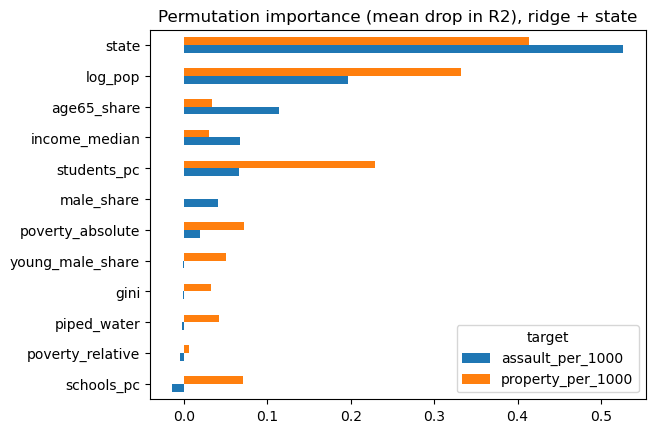

target,assault_per_1000,property_per_1000
log_pop,0.196669,0.332603
students_pc,0.066511,0.228678
schools_pc,-0.013848,0.070486
income_median,0.067035,0.030337
poverty_absolute,0.019375,0.072213
poverty_relative,-0.004858,0.006057
gini,-0.001346,0.032937
piped_water,-0.002922,0.042223
young_male_share,-0.000570,0.049883
age65_share,0.114091,0.034213


In [89]:
# several features are highly correlated (income_mean vs income_median 0.98), so ridge coefficients are hard
# to read. Permutation importance measures how much the cross-validated R2 drops when one feature is shuffled.
# income_mean is dropped first: while income_median stays in place, shuffling income_mean would show little
# drop (and the other way round), which understates income. State is shuffled as one column, not per 0/1 column.
# - reduced_features: all_features without income_mean; prints cross-validated R2 for both sets to check the
# drop does not lower accuracy
# - for each fold of 5-fold CV (repeated 5 times), fits ridge + state on the training districts, shuffles each
# column of the test districts 20 times and records the mean drop in R2; the drops are averaged over folds
from sklearn.inspection import permutation_importance

reduced_features = [feature for feature in all_features if feature != 'income_mean']
reduced_features_with_state = reduced_features + ['state']
for target_name in target_columns:
    print(target_name, 'all_feats:', cross_validated_r2(make_ridge_with_state, features_2022[features_with_state], average_rates[target_name]),
          'reduced_feats:', cross_validated_r2(make_ridge_with_state, features_2022[reduced_features_with_state], average_rates[target_name]))

importance_rows = []
for target_name in target_columns:
    for repeat_index in range(5):
        for train_index, test_index in KFold(5, shuffle=True, random_state=repeat_index).split(features_2022):
            model = make_ridge_with_state().fit(features_2022[reduced_features_with_state].iloc[train_index], average_rates[target_name].iloc[train_index])
            permutation_result = permutation_importance(model, features_2022[reduced_features_with_state].iloc[test_index], average_rates[target_name].iloc[test_index], scoring='r2', n_repeats=20, random_state=0)
            # pairs each column name with its mean drop in R2 for this fold
            importance_rows.append({'target': target_name, **dict(zip(reduced_features_with_state, permutation_result.importances_mean))})
# mean over all folds and repeats, then transposed so the features are rows
importance = pd.DataFrame(importance_rows).groupby('target').mean().T

importance.sort_values('assault_per_1000').plot.barh()
plt.title('Permutation importance (mean drop in R2), ridge + state')
plt.show()
importance

# # K-means without the crime columns

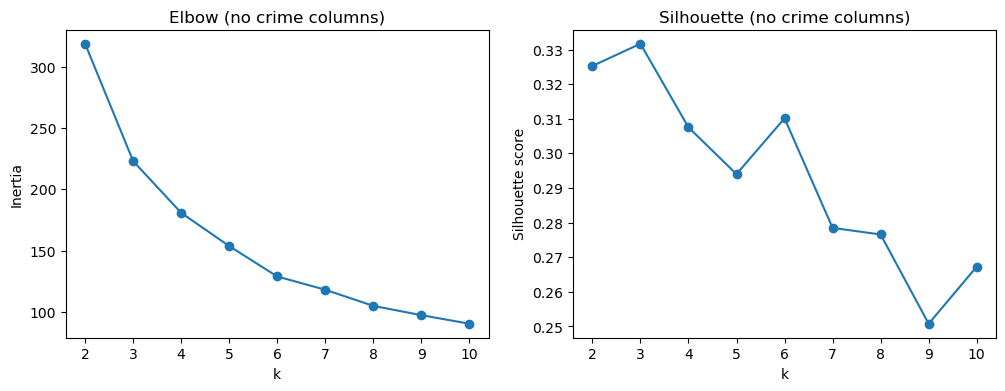

,k,inertia,silhouette
0,2,318.810175,0.325262
1,3,223.055291,0.331687
2,4,180.852606,0.307524
3,5,153.721317,0.294008
4,6,128.919928,0.310137
5,7,118.114594,0.278475
6,8,104.946260,0.276569
7,9,97.381925,0.250780
8,10,90.397210,0.267248


In [90]:
# the original k-means includes assault_per_1000 and property_per_1000 as inputs, so cluster membership is
# partly defined by crime. Clustering without the crime columns, then comparing crime rates between clusters,
# shows whether district types formed from the other features differ in crime.
# - same features as the original clustering minus the two crime rates (this equals model_features)
# - same k-means settings and the same elbow / silhouette check for k = 2 to 10
cluster_features_no_crime = ['log_pop', 'students_pc', 'schools_pc', 'income_median']
scaled_no_crime = StandardScaler().fit_transform(features_2022[cluster_features_no_crime])

inertias_no_crime = []
silhouette_scores_no_crime = []
for cluster_count in k_values:
    kmeans_model = KMeans(n_clusters=cluster_count, n_init=10, random_state=0).fit(scaled_no_crime)
    inertias_no_crime.append(kmeans_model.inertia_)
    silhouette_scores_no_crime.append(silhouette_score(scaled_no_crime, kmeans_model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertias_no_crime, marker='o')
axes[0].set_title('Elbow (no crime columns)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(k_values, silhouette_scores_no_crime, marker='o')
axes[1].set_title('Silhouette (no crime columns)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
plt.show()

pd.DataFrame({'k': k_values, 'inertia': inertias_no_crime, 'silhouette': silhouette_scores_no_crime})

cluster
0    24
1    70
2    37
Name: count, dtype: int64


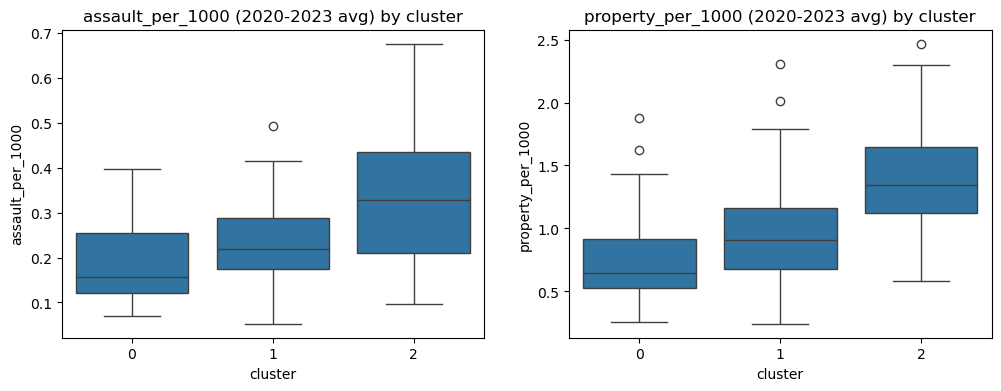

,log_pop,students_pc,schools_pc,income_median,assault_per_1000,property_per_1000
cluster,,,,,,
0,3.763267,214.159781,1.142984,3684.626094,0.185388,0.784339
1,4.802180,160.155937,0.512577,4322.963842,0.233152,0.951695
2,6.127288,145.649328,0.237423,7047.539638,0.334254,1.381743


In [91]:
# compares the 2020-2023 average crime rates between clusters that were formed without crime data.
# fits k-means with 3 clusters (k = 3 has the highest silhouette score in the table above), then shows cluster
# sizes, the mean of each feature and crime rate per cluster, and box plots of the two crime rates by cluster.
chosen_k_no_crime = 3
kmeans_no_crime = KMeans(n_clusters=chosen_k_no_crime, n_init=10, random_state=0).fit(scaled_no_crime)

no_crime_profile = features_2022[cluster_features_no_crime].join(average_rates)
no_crime_profile['cluster'] = kmeans_no_crime.labels_
print(no_crime_profile['cluster'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for target_index, target_name in enumerate(target_columns):
    sns.boxplot(data=no_crime_profile, x='cluster', y=target_name, ax=axes[target_index])
    axes[target_index].set_title(f'{target_name} (2020-2023 avg) by cluster')
plt.show()

no_crime_profile.groupby('cluster').mean()

# Model improvements

The cells below add the changes that raised the cross-validated R² in testing. The setup is the same as the cross-sectional section (2020–2023 average target, 5-fold CV over districts, repeated 10 times).

- Survey features averaged over 2019 and 2022, plus post-secondary students and tertiary schools per 1,000 people
- Poisson GLM + state with `alpha=0.1`
- Average of the ridge + state and Poisson + state predictions

In [92]:
# - district survey values can change a lot between survey rounds (for example, Batu Pahat's poverty_relative
# is 9.0 in 2019 and 19.4 in 2022). Averaging the 2019 and 2022 rounds reduces that variation.
# - students_post_secondary and schools_tertiary are already in df_district but were not used as features.
# - features_2022_v2: copy of features_2022 with the survey features (income, poverty, gini, piped water)
# replaced by the mean of their 2019 and 2022 values
# - post_sec_pc: post-secondary students per 1,000 people
# - tertiary_schools_pc: tertiary schools per 1,000 people
# - features_v2 / features_v2_with_state: the new feature list, without and with state
survey_values_2019 = district_panel[district_panel['year'] == 2019].set_index('district')[survey_features].loc[features_2022.index]
assert not survey_values_2019.isna().any().any()

features_2022_v2 = features_2022.copy()
features_2022_v2[survey_features] = (features_2022[survey_features] + survey_values_2019) / 2
features_2022_v2['post_sec_pc'] = features_2022_v2['students_post_secondary'] / features_2022_v2['population']
features_2022_v2['tertiary_schools_pc'] = features_2022_v2['schools_tertiary'] / features_2022_v2['population']

features_v2 = all_features + ['post_sec_pc', 'tertiary_schools_pc']
features_v2_with_state = features_v2 + ['state']
assert not features_2022_v2[features_v2].isna().any().any()

In [93]:
# shows how much each change adds on its own and together, using the same model (ridge + state) and folds.
# cross-validated R2 for 4 setups:
# - all_features with 2022 survey values (the previous setup)
# - + post_sec_pc and tertiary_schools_pc only
# - survey features averaged over 2019/2022 only
# - both changes together
features_2022_edu = features_2022.copy()
features_2022_edu['post_sec_pc'] = features_2022_v2['post_sec_pc']
features_2022_edu['tertiary_schools_pc'] = features_2022_v2['tertiary_schools_pc']

# label: (table, columns to use)
setups = {
    '1. all_feats (previous)': (features_2022, features_with_state),
    '2. + post_sec_pc, tertiary_schools_pc': (features_2022_edu, features_v2_with_state),
    '3. survey features averaged 2019/2022': (features_2022_v2, features_with_state),
    '4. both changes': (features_2022_v2, features_v2_with_state),
}
setup_rows = []
for setup_label, (setup_table, setup_columns) in setups.items():
    for target_name in target_columns:
        setup_rows.append({'setup': setup_label, 'crime': target_name,
                           'cv_R2': cross_validated_r2(make_ridge_with_state, setup_table[setup_columns], average_rates[target_name])})
pd.DataFrame(setup_rows).pivot(index='setup', columns='crime', values='cv_R2')

crime,assault_per_1000,property_per_1000
setup,,
1. all_feats (previous),0.505642,0.423592
"2. + post_sec_pc, tertiary_schools_pc",0.506550,0.451038
3. survey features averaged 2019/2022,0.514330,0.454520
4. both changes,0.514843,0.485775


In [94]:
# the Poisson model had the highest assault score in the model comparison, where its penalty strength (alpha)
# was fixed at 0.01. This cell compares a few alpha values on the new features.
# cross-validated R2 for Poisson GLM + state with alpha 0.001, 0.01, 0.1 and 1, population-weighted as before.
# In testing, alpha=0.1 scored highest for both crime types (for assault, 0.01 was almost the same), so it is
# used below.
# Because alpha is picked using these same CV scores, the 0.1 result is slightly optimistic. Picking alpha inside
# each training fold (for example GridSearchCV within the loop) would avoid this.
from functools import partial

def make_poisson_with_state(alpha=0.1):
    return make_pipeline(make_state_encoder(), StandardScaler(), PoissonRegressor(alpha=alpha, max_iter=1000))

alpha_rows = []
for alpha_value in [0.001, 0.01, 0.1, 1.0]:
    # partial returns make_poisson_with_state with alpha already set, so it can be called with no arguments
    # like the other model functions
    make_model = partial(make_poisson_with_state, alpha=alpha_value)
    for target_name in target_columns:
        alpha_rows.append({'alpha': alpha_value, 'crime': target_name,
                           'cv_R2': cross_validated_r2(make_model, features_2022_v2[features_v2_with_state], average_rates[target_name], weights=population_weights)})
pd.DataFrame(alpha_rows).pivot(index='alpha', columns='crime', values='cv_R2')

crime,assault_per_1000,property_per_1000
alpha,,
0.001,0.484245,0.357419
0.010,0.544892,0.468132
0.100,0.545161,0.498794
1.000,0.352829,0.370786


In [95]:
# ridge and Poisson are fitted differently and make different errors, so the average of their predictions can
# have a smaller error than either one. In testing this gave the highest property score; for assault the
# average and Poisson alone scored about the same.
# - cross_validated_predictions: same loop as cross_validated_r2, but returns the out-of-fold predictions of
# each repeat, so two models can be combined on the same folds
# - fits ridge + state and Poisson + state (alpha=0.1) on the new features, averages their predictions in each
# repeat, and computes R2
# - the summary compares the previous ridge + state (all_features), each model on the new features, and the average
def cross_validated_predictions(make_model, features, target, weights=None, n_repeats=10):
    predictions_per_repeat = []
    for repeat_index in range(n_repeats):
        out_of_fold = pd.Series(np.nan, index=target.index)
        for train_index, test_index in KFold(5, shuffle=True, random_state=repeat_index).split(features):
            model = make_model()
            fit_arguments = {}
            if weights is not None:
                fit_arguments = {model.steps[-1][0] + '__sample_weight': weights.iloc[train_index].values}
            model.fit(features.iloc[train_index], target.iloc[train_index], **fit_arguments)
            out_of_fold.iloc[test_index] = model.predict(features.iloc[test_index])
        predictions_per_repeat.append(out_of_fold)
    return predictions_per_repeat

def mean_r2_over_repeats(predictions_per_repeat, target):
    return np.mean([r2_score(target, repeat_predictions) for repeat_predictions in predictions_per_repeat])

summary_rows = []
for target_name in target_columns:
    target_values = average_rates[target_name]
    ridge_previous = cross_validated_predictions(make_ridge_with_state, features_2022[features_with_state], target_values)
    ridge_new = cross_validated_predictions(make_ridge_with_state, features_2022_v2[features_v2_with_state], target_values)
    poisson_new = cross_validated_predictions(make_poisson_with_state, features_2022_v2[features_v2_with_state], target_values, weights=population_weights)
    # both models used the same folds in each repeat, so the predictions can be paired repeat by repeat
    average_new = [(ridge_predictions + poisson_predictions) / 2 for ridge_predictions, poisson_predictions in zip(ridge_new, poisson_new)]
    summary_rows += [
        {'model': '1. ridge + state, all_feats (previous)', 'crime': target_name, 'cv_R2': mean_r2_over_repeats(ridge_previous, target_values)},
        {'model': '2. ridge + state, new features', 'crime': target_name, 'cv_R2': mean_r2_over_repeats(ridge_new, target_values)},
        {'model': '3. poisson + state (alpha=0.1), new features', 'crime': target_name, 'cv_R2': mean_r2_over_repeats(poisson_new, target_values)},
        {'model': '4. average of 2 and 3', 'crime': target_name, 'cv_R2': mean_r2_over_repeats(average_new, target_values)},
    ]
pd.DataFrame(summary_rows).pivot(index='model', columns='crime', values='cv_R2')

crime,assault_per_1000,property_per_1000
model,,
"1. ridge + state, all_feats (previous)",0.505642,0.423592
"2. ridge + state, new features",0.514843,0.485775
"3. poisson + state (alpha=0.1), new features",0.545161,0.498794
4. average of 2 and 3,0.545208,0.505923
